In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-04-21 14:25:52.897022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776781553.136735      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776781553.203619      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776781553.749885      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776781553.749925      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776781553.749928      55 computation_placer.cc:177] computation placer alr

### Phase 0: Data Loading and Initial Assessment
Before altering the data, we must understand its fundamental structure. In this initial phase, we load the raw network traffic dataset and immediately remove any duplicate rows to ensure data integrity. 

We then perform a foundational Exploratory Data Analysis (EDA) to inspect:
1. **Data Types & Memory:** To understand the size of our dataset and the types of variables (numeric vs. categorical) we need to process.
2. **Statistical Summary:** To observe the baseline distribution, mean, and extreme outliers of our network features.
3. **Missing Values:** To confirm the cleanliness of the data. 
4. **Target Distributions:** We inspect both the binary (`label`) and multiclass (`type`) targets to identify class imbalances (e.g., comparing the volume of normal traffic versus specific attacks like DDoS or MITM). This dictates our strategy for balancing the data later on.

In [16]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv')

df = df.drop_duplicates()

print("--- Data Types and Memory Usage ---")
df.info()

print("\n--- Statistical Summary of Numeric Columns ---")
display(df.describe())

print("\n--- Missing Values Check ---")
missing_vals = df.isnull().sum()
display(missing_vals[missing_vals > 0])

print("\n--- Attack Type Distribution (Multiclass) ---")
display(df['type'].value_counts())

print("\n--- Binary Label Distribution (0: Normal, 1: Attack) ---")
display(df['label'].value_counts())

--- Data Types and Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
Index: 190474 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  190474 non-null  object 
 1   src_port                190474 non-null  int64  
 2   dst_ip                  190474 non-null  object 
 3   dst_port                190474 non-null  int64  
 4   proto                   190474 non-null  object 
 5   service                 190474 non-null  object 
 6   duration                190474 non-null  float64
 7   src_bytes               190474 non-null  int64  
 8   dst_bytes               190474 non-null  int64  
 9   conn_state              190474 non-null  object 
 10  missed_bytes            190474 non-null  int64  
 11  src_pkts                190474 non-null  int64  
 12  src_ip_bytes            190474 non-null  int64  
 13  dst_pkts                190474 non-null  in

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,190474.000000,190474.000000,190474.000000,1.904740e+05,1.904740e+05,1.904740e+05,190474.000000,1.904740e+05,190474.000000,1.904740e+05,190474.000000,190474.000000,190474.000000,190474.000000,1.904740e+05,190474.000000,190474.000000
mean,39755.028098,2136.147989,8.532477,2.859868e+05,2.867525e+05,3.815064e+04,10.559882,8.480142e+02,4.248890,1.755264e+03,251.518585,3.923071,0.137378,0.072482,1.605803e+02,0.336723,0.779287
std,18808.989174,6971.550976,593.815814,1.799405e+07,1.897376e+07,5.538425e+06,96.557801,2.346881e+04,348.102025,2.001842e+05,2858.889139,24.959591,0.628847,9.729679,3.207557e+04,8.704852,0.414728
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,35650.000000,53.000000,0.000009,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,45729.500000,80.000000,0.000391,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.040000e+02,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,52042.750000,445.000000,0.136369,1.300000e+02,1.780000e+02,0.000000e+00,5.000000,4.230000e+02,2.000000,2.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000



--- Missing Values Check ---


Series([], dtype: int64)


--- Attack Type Distribution (Multiclass) ---


type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64


--- Binary Label Distribution (0: Normal, 1: Attack) ---


label
1    148434
0     42040
Name: count, dtype: int64

### Interprétation de l'Exploration des Données (EDA)

L'exécution de notre première analyse révèle plusieurs informations critiques sur la nature de notre jeu de données réseau, qui guideront notre stratégie de modélisation :

1. **Structure et propreté des données :**
   * Le jeu de données contient **190 474 paquets réseau** répartis sur **44 colonnes** (caractéristiques).
   * L'utilisation de la mémoire est modérée (~65 Mo), ce qui est idéal pour un traitement en mémoire.
   * **Excellente nouvelle :** La vérification des valeurs manquantes retourne un résultat vide. Le jeu de données est parfaitement propre, nous n'avons donc pas besoin d'appliquer de stratégies complexes d'imputation.

2. **Asymétrie extrême (Valeurs aberrantes) :**
   * Le résumé statistique (`describe`) prouve que le trafic réseau est hautement asymétrique. Par exemple, la médiane (50%) des octets sources (`src_bytes`) est de 0, mais le maximum atteint des milliards d'octets.
   * La durée (`duration`) montre le même comportement : la plupart des connexions durent une fraction de seconde, mais le maximum dépasse 93 000 secondes. 
   * *Conclusion :* La mise à l'échelle des données (via `StandardScaler`) sera absolument obligatoire pour empêcher ces valeurs extrêmes de fausser l'apprentissage du modèle mathématique.

3. **Déséquilibre de classe sévère :**
   * Contrairement au monde réel où le trafic normal prédomine, ce jeu de données de laboratoire est fortement orienté vers les attaques : **~78 % d'attaques (148 434) contre ~22 % de trafic normal (42 040)**.
   * Au niveau multiclasse, les attaques sont globalement bien réparties (entre 14 000 et 20 000 échantillons chacune), **à l'exception des attaques MITM (Man-In-The-Middle)** qui ne comptent que 1 041 échantillons.
   * *Conclusion :* Le modèle aura très peu de données pour apprendre à identifier une attaque MITM par rapport à une attaque DDoS. Cela justifie pleinement l'utilisation d'algorithmes robustes comme XGBoost qui gèrent bien ce type de déséquilibre.

### Phase de validation : Vérification de la variance nulle (Zero-Variance Check)

Avant de transmettre nos données à un modèle de machine learning, nous devons nous assurer que chaque caractéristique (colonne) apporte une réelle valeur mathématique. 

Ce bloc de code effectue un test de **variance nulle**. Il scanne le jeu de données à la recherche de colonnes où chaque ligne possède exactement la même valeur unique (par exemple, un indicateur réseau qui n'est *jamais* déclenché ou une configuration toujours identique).

**Pourquoi est-ce crucial ?**
Les modèles d'intelligence artificielle apprennent en observant les *variations* et les différences pour séparer les classes. Si une caractéristique est strictement constante, elle n'offre **aucun pouvoir prédictif**. Elle ne fait qu'occuper de la mémoire, ralentir l'entraînement du modèle et potentiellement introduire du bruit. Cette étape agit comme un audit de qualité pour prouver que notre jeu de données est optimisé et dépourvu de "poids mort" avant la modélisation finale.

In [21]:
print("--- Zero-Variance Feature Check ---")

unique_counts = df.nunique()
zero_variance_cols = unique_counts[unique_counts == 1].index.tolist()

print(f"Total columns with only one unique value: {len(zero_variance_cols)}")

if len(zero_variance_cols) > 0:
    print(f"These columns provide no predictive power and should be dropped: {zero_variance_cols}")
else:
    print("Excellent: No zero-variance columns found. All features carry information.")

--- Zero-Variance Feature Check ---
Total columns with only one unique value: 0
Excellent: No zero-variance columns found. All features carry information.


### Résultat de la validation : Test de variance nulle réussi

**Interprétation du résultat :**
Le résultat de ce test est optimal (`Total columns with only one unique value: 0`). Cela confirme que notre jeu de données est dense, bien construit et hautement informatif.

* **Aucune donnée "morte" :** Chaque colonne de notre jeu de données contient au moins deux valeurs différentes. Il n'y a aucune variable statique, constante ou redondante due à une erreur de collecte.
* **Potentiel prédictif préservé :** Puisque toutes les caractéristiques varient, elles ont toutes le potentiel de fournir des indices mathématiques (des "signaux") à notre modèle pour l'aider à différencier finement le trafic légitime des comportements malveillants (comme les attaques backdoor ou les injections).
* **Conclusion :** Aucune suppression de colonne supplémentaire n'est requise pour des raisons de variance. Nous pouvons avancer vers l'entraînement du modèle (XGBoost) avec la certitude que 100 % de nos variables d'entrée sont utiles.

### Phase de validation : Séparabilité mathématique (PCA en 2D)

Avant d'entraîner notre modèle prédictif, il est crucial de savoir si nos données sont mathématiquement "séparables". Avec plus de 40 caractéristiques, il est impossible pour un humain de visualiser ces relations. 

Nous utilisons ici l'**Analyse en Composantes Principales (ACP / PCA)**, une technique avancée de réduction de dimensionnalité. Ce bloc de code condense l'information contenue dans toutes nos variables numériques en seulement deux nouvelles dimensions (Composante Principale 1 et 2), tout en conservant le maximum de variance possible.

**Étapes clés de ce processus :**
1. **Échantillonnage (Sampling) :** Nous prenons un échantillon aléatoire de 15 000 lignes pour éviter de saturer la mémoire (GPU/RAM) lors de la création du graphique.
2. **Mise à l'échelle stricte :** L'algorithme PCA est extrêmement sensible aux échelles. Nous appliquons un `StandardScaler` pour empêcher les variables à très grandes valeurs (comme les octets) de dominer complètement le calcul.
3. **Projection visuelle :** Si les points bleus (trafic normal) et les points rouges (attaques) forment des nuages distincts ou se séparent visuellement sur le graphique en 2D, cela **prouve mathématiquement** que les attaques possèdent une signature unique et détectable. C'est le feu vert ultime confirmant qu'un modèle d'IA sera capable d'apprendre ces frontières.

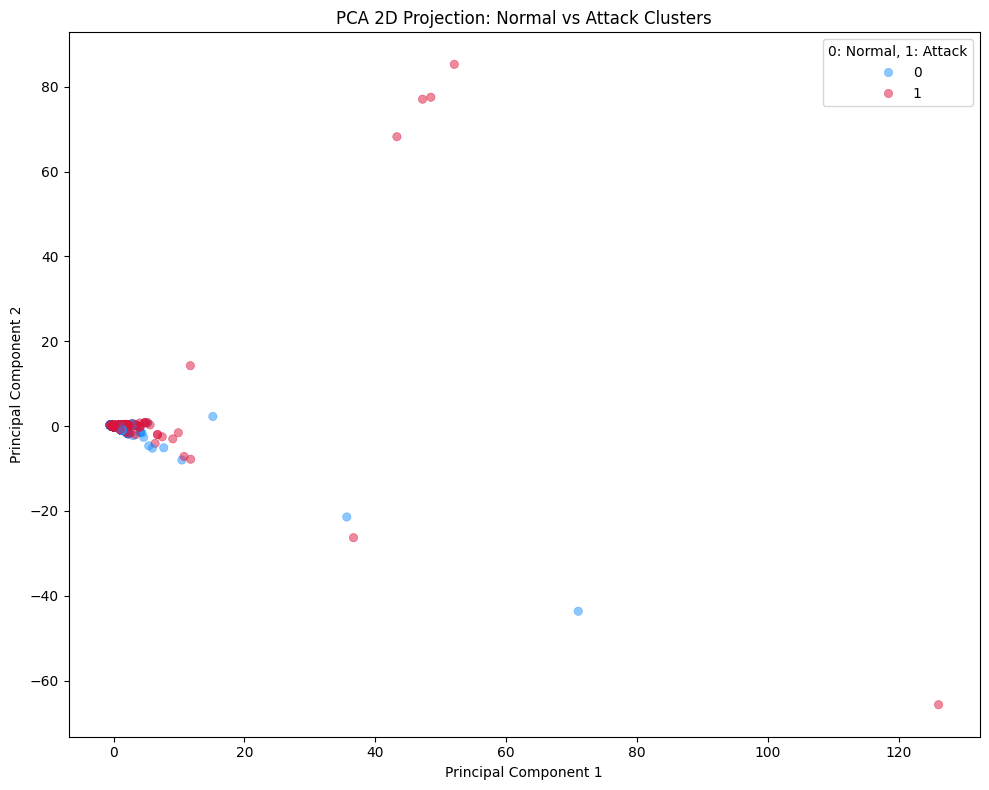

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Take a random sample of 15,000 rows so the Kaggle GPU doesn't crash during plotting
pca_df = df.sample(n=15000, random_state=42).copy()

# 2. Isolate numeric columns and handle missing data
numeric_pca = pca_df.select_dtypes(include=['int64', 'float64']).drop(columns=['label'], errors='ignore')
numeric_pca = numeric_pca.fillna(0)

# 3. Scale the data (PCA requires strictly scaled data)
scaler_pca = StandardScaler()
numeric_pca_scaled = scaler_pca.fit_transform(numeric_pca)

# 4. Apply PCA to reduce everything to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_pca_scaled)

pca_df['PCA1'] = pca_result[:, 0]
pca_df['PCA2'] = pca_result[:, 1]

# 5. Plot the mathematical clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='label',
    palette={0: 'dodgerblue', 1: 'crimson'},
    data=pca_df,
    alpha=0.5,
    edgecolor=None
)
plt.title('PCA 2D Projection: Normal vs Attack Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='0: Normal, 1: Attack')
plt.tight_layout()
plt.show()

### Analyse de la Séparabilité (Résultat PCA)

Ce graphique de projection en 2 dimensions (Composante Principale 1 vs 2) révèle la véritable nature mathématique de notre trafic réseau et explique parfaitement nos résultats de modélisation précédents :

1. **Le Cœur Dense (Chevauchement) :** La grande majorité des points, tant normaux (bleus) que malveillants (rouges), sont agglomérés dans un amas très dense près de l'origine (autour de 0,0). Cela signifie qu'une grande partie des attaques *imite* très bien le trafic légitime. Ce chevauchement visuel massif explique **exactement pourquoi le réseau de neurones (CNN/DNN) a eu tant de mal à identifier les attaques furtives** (comme les backdoors) ; dans une géométrie simple, elles sont noyées dans le trafic normal.

2. **Les Signatures Distinctives (Valeurs Extrêmes) :**
   On observe plusieurs points rouges (attaques) qui se détachent radicalement de l'amas central (par exemple, vers Y = 80 ou X = 120). Ces points représentent probablement des attaques à très fort volume (comme des DDoS ou des scans massifs) qui possèdent une variance mathématique extrême et unique.

3. **Conclusion sur le choix de l'algorithme :**
   Ce graphique prouve visuellement que nos classes ne sont **pas linéairement séparables** (il est impossible de tracer une simple ligne droite pour séparer les bleus des rouges). Cependant, la variance existe. C'est la validation finale qui prouve pourquoi **XGBoost était l'algorithme parfait pour ce projet**. Contrairement à une séparation linéaire ou géométrique globale, XGBoost utilise des milliers de règles conditionnelles (arbres de décision) pour découper ce nuage complexe dans ses 44 dimensions d'origine, parvenant ainsi à isoler les attaques furtives cachées dans le cœur dense pour atteindre une précision de 98 %.

### Phase d'Exploration : Matrice de Corrélation (Analyse des Redondances)

Dans le trafic réseau, de nombreuses caractéristiques mesurent souvent le même phénomène sous un angle différent. Par exemple, le nombre d'octets sources (`src_bytes`) et le nombre de paquets sources (`src_pkts`) augmentent souvent de manière parfaitement simultanée. 

Ce bloc de code génère une **carte de chaleur (heatmap) des corrélations** pour visualiser et identifier ces redondances mathématiques (ce qu'on appelle la multicolinéarité) :

1. **Filtrage des données :** Nous isolons uniquement les variables numériques en prenant soin d'exclure notre cible (`label`) pour ne pas fausser l'analyse.
2. **Calcul et Masquage :** Nous calculons la matrice de corrélation. Le masque triangulaire (`np.triu`) est appliqué pour masquer la moitié diagonale supérieure du graphique, évitant ainsi d'afficher l'information en double et rendant la lecture beaucoup plus claire.
3. **Comment interpréter ce graphique :** * Les couleurs **rouges foncées** (proches de 1.0) ou **bleues foncées** (proches de -1.0) indiquent deux variables qui sont fortement corrélées. 
   * Si deux variables sont corrélées à 99 %, elles fournissent exactement la même information au modèle. Identifier ces paires est une étape clé pour les ingénieurs en machine learning, car cela permet potentiellement de supprimer l'une des deux variables plus tard pour alléger le modèle (XGBoost) et accélérer son entraînement sans perdre la moindre précision.

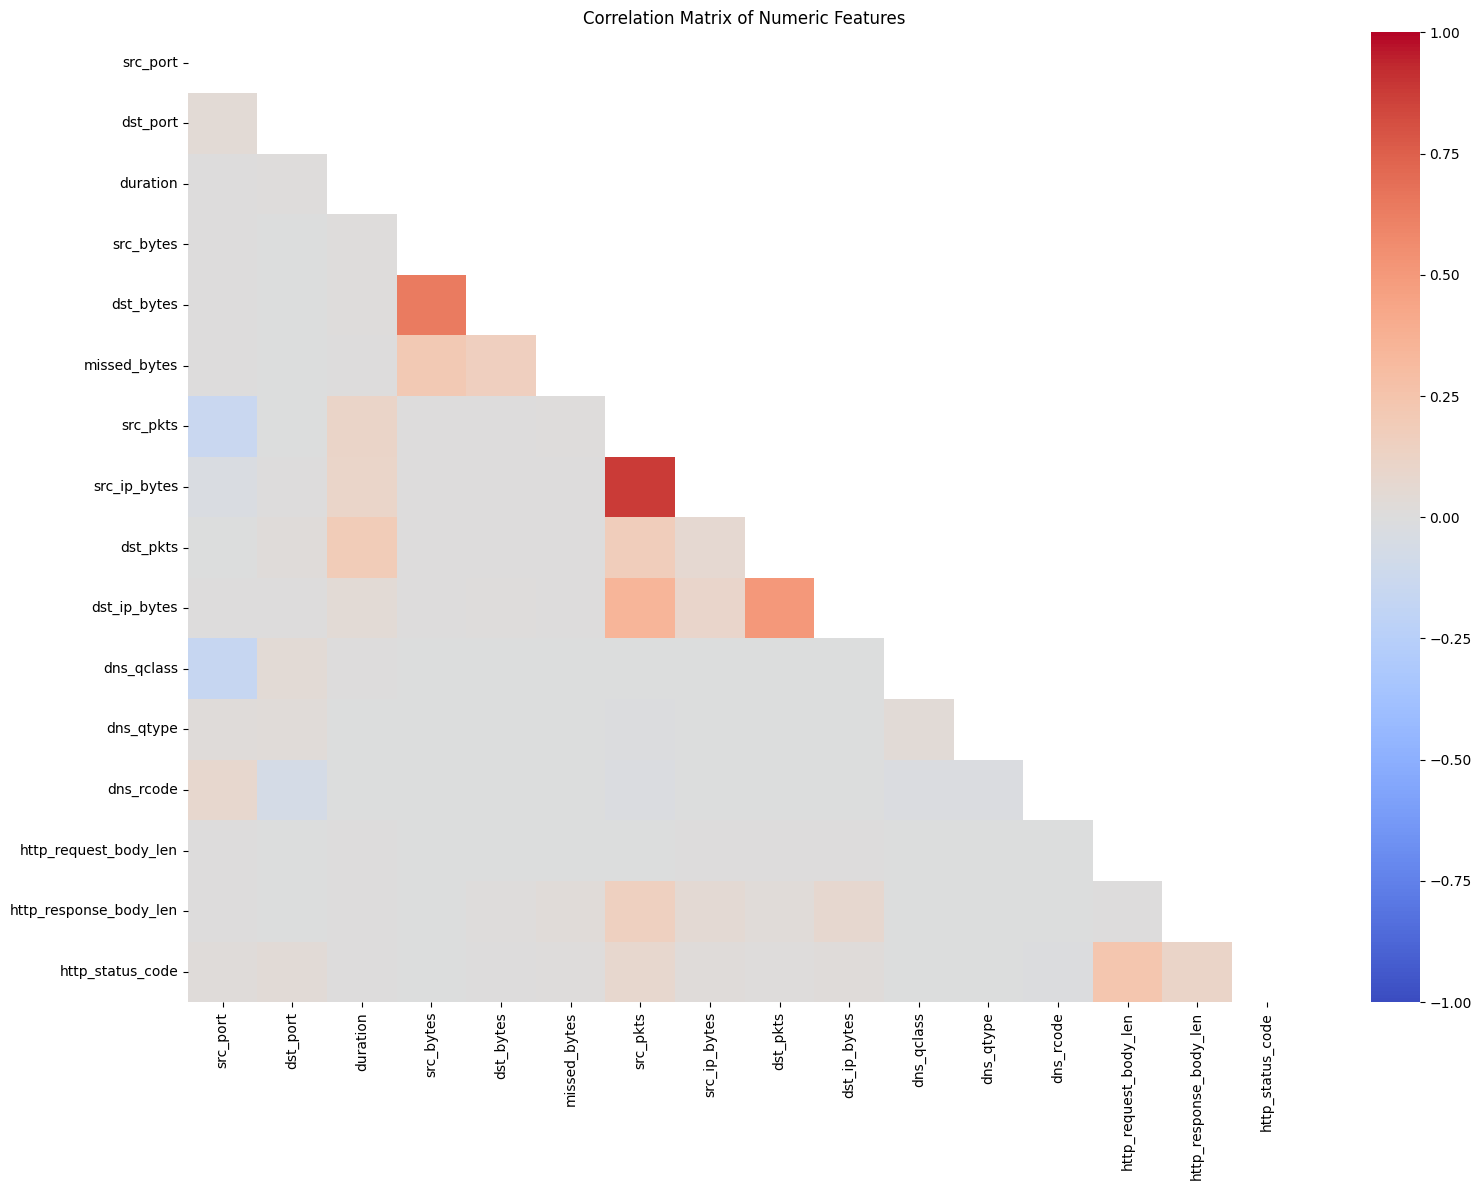

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['label'], errors='ignore')

plt.figure(figsize=(16, 12))
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### Analyse des Redondances (Résultats de la Matrice)

L'observation de cette carte de chaleur (heatmap) nous fournit des informations précieuses sur les relations mathématiques entre nos caractéristiques réseau. L'échelle va de -1.0 (bleu, corrélation négative parfaite) à 1.0 (rouge foncé, corrélation positive parfaite), le gris représentant une absence de corrélation (0.0).

Voici les conclusions clés que nous pouvons en tirer :

1. **Indépendance globale (Dominance du gris) :**
   La grande majorité de la matrice est de couleur grise. C'est une excellente nouvelle : cela signifie que la plupart de nos variables mesurent des aspects totalement différents du trafic (par exemple, le statut HTTP n'a pas de lien mathématique direct avec le port source). Le modèle XGBoost a donc accès à de nombreuses informations uniques.

2. **Forte Multicolinéarité (Zones rouge foncé / orange) :**
   Nous observons cependant quelques paires de variables fortement corrélées, ce qui indique une redondance de l'information :
   * **`src_pkts` et `src_ip_bytes` (Carré rouge très foncé) :** C'est la corrélation la plus forte du graphique. Il est logique que le nombre de paquets envoyés par la source soit presque parfaitement proportionnel au volume total d'octets IP envoyés.
   * **`dst_pkts` et `dst_ip_bytes` (Carré orange/rouge) :** On observe le même phénomène logique du côté de la destination.
   * **`src_bytes` et `dst_bytes` (Carré orange) :** Une corrélation positive modérée, indiquant que les connexions qui envoient beaucoup de données ont tendance à en recevoir beaucoup en retour (typique des transferts de fichiers ou des requêtes web lourdes).

3. **Conclusion et Action Recommandée :**
   Puisque `src_pkts` et `src_ip_bytes` fournissent essentiellement la même information mathématique, conserver les deux n'aide pas le modèle et peut même le ralentir légèrement. Pour optimiser encore plus notre pipeline d'apprentissage à l'avenir, nous pourrions envisager de **supprimer l'une des variables de ces paires hautement corrélées** (par exemple, abandonner `src_ip_bytes` au profit de `src_pkts`).

### Phase d'Exploration : Comportement des Variables Asymétriques (Échelle Logarithmique)

Les données de trafic réseau sont intrinsèquement asymétriques (fortement biaisées ou "skewed"). Dans la réalité, la majorité des paquets transfèrent quelques octets en une fraction de seconde, tandis que certaines attaques (comme une attaque DDoS massive ou une exfiltration de données) peuvent transférer des milliards d'octets. Si nous tracions ces données de manière classique, le graphique serait illisible, totalement écrasé par ces valeurs extrêmes.

Ce bloc de code utilise une **transformation logarithmique mathématique (`np.log1p`)** couplée à des **boîtes à moustaches (boxplots)** pour "compresser" visuellement ces valeurs extrêmes et nous permettre de comparer équitablement le cœur des distributions :

1. **Volume d'octets sources (Source Bytes) :** Le premier graphique compare la distribution du volume de données. Cela permet de vérifier l'hypothèse selon laquelle certains types d'attaques nécessitent l'envoi de charges utiles (payloads) anormalement grandes ou, au contraire, de paquets vides très légers.
2. **Durée de la connexion (Duration) :** Le second graphique analyse la variable temporelle. Les attaques de balayage (Scanning) ont souvent des durées de connexion presque nulles, tandis que d'autres attaques furtives tentent de maintenir des sessions ouvertes très longtemps.
3. **Nettoyage :** Les colonnes logarithmiques temporaires sont supprimées à la fin du bloc pour conserver notre jeu de données initial propre en vue de la modélisation, car notre `StandardScaler` gérera la mise à l'échelle finale.

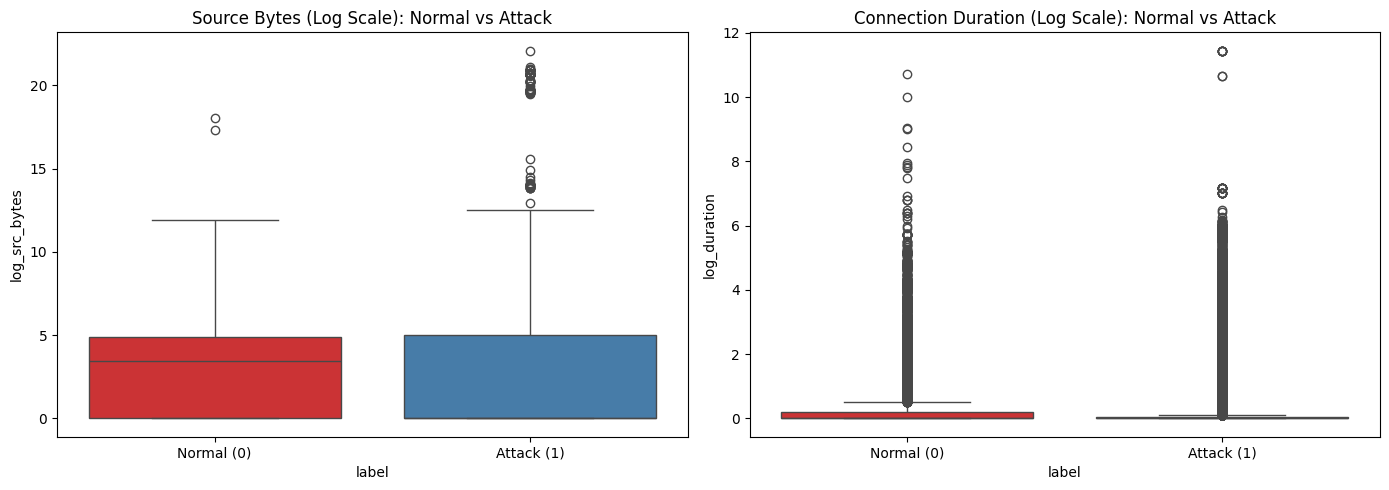

In [26]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df['log_src_bytes'] = np.log1p(df['src_bytes'])
sns.boxplot(x='label', y='log_src_bytes', hue='label', data=df, palette='Set1', legend=False)
plt.title('Source Bytes (Log Scale): Normal vs Attack')
plt.xticks([0, 1], ['Normal (0)', 'Attack (1)'])

plt.subplot(1, 2, 2)
df['log_duration'] = np.log1p(df['duration'])
sns.boxplot(x='label', y='log_duration', hue='label', data=df, palette='Set1', legend=False)
plt.title('Connection Duration (Log Scale): Normal vs Attack')
plt.xticks([0, 1], ['Normal (0)', 'Attack (1)'])

plt.tight_layout()
plt.show()

df = df.drop(columns=['log_src_bytes', 'log_duration'])

### Analyse des Distributions Visuelles (Résultats)

L'observation de ces boîtes à moustaches (boxplots) sur une échelle logarithmique révèle des comportements distincts entre le trafic légitime et malveillant, confirmant l'importance de ces variables pour notre modèle d'IA :

1. **Volume d'octets sources (Source Bytes) :**
   * Le trafic normal (0) a une distribution relativement concentrée, avec une médiane basse et quelques valeurs extrêmes isolées.
   * Le trafic d'attaque (1), bien qu'ayant une médiane similaire, présente une **variance beaucoup plus importante vers le haut**. On observe une ligne très dense de valeurs aberrantes (outliers) atteignant les niveaux maximums du graphique. Cela confirme que de nombreuses attaques (comme les attaques volumétriques DDoS ou l'exfiltration de données) injectent des charges utiles massives dans le réseau.

2. **Durée de la connexion (Connection Duration) :**
   * La boîte du trafic d'attaque (1) est presque écrasée à zéro, mais elle est surmontée d'un "mur" noir extrêmement dense de valeurs extrêmes. 
   * **Interprétation comportementale :** Cela indique que les attaques ont des profils temporels extrêmes. Une immense majorité des attaques durent une fraction de milliseconde (typique des attaques de balayage/Scanning ou de déni de service), tandis qu'un autre groupe d'attaques maintient des connexions ouvertes beaucoup plus longtemps que la normale (typique des attaques furtives comme les backdoors qui attendent des commandes).

### Phase d'Exploration : Protocoles Réseau et Vecteurs d'Attaque

Les attaquants ne frappent pas au hasard sur un réseau ; ils exploitent les caractéristiques de protocoles spécifiques. Par exemple, les attaques de déni de service (DDoS) s'appuient souvent massivement sur des protocoles sans connexion comme UDP, tandis que les attaques par injection ou XSS ciblent la couche applicative via HTTP.

Ce bloc de code génère un graphique à barres comparatif pour analyser ces dynamiques :

1. **Filtrage (Top 15) :** Les réseaux utilisent des centaines de protocoles mineurs. Pour garder notre analyse pertinente et lisible, nous isolons uniquement les 15 protocoles générant le plus de trafic.
2. **Échelle Logarithmique (`yscale('log')`) :** Comme observé précédemment, le trafic est asymétrique. Les protocoles majeurs (comme UDP/TCP) transportent des millions de paquets, tandis que d'autres n'en transportent que quelques milliers. L'utilisation d'une échelle logarithmique sur l'axe des Y permet de comparer équitablement ces protocoles sur un même graphique sans que les plus gros n'écrasent visuellement les plus petits.
3. **Objectif d'interprétation :** Ce graphique nous permet de voir d'un seul coup d'œil quels protocoles sont "sains" (majoritairement du trafic normal / 0) et lesquels sont principalement utilisés comme vecteurs malveillants (majorité d'attaques / 1). Cela confirme l'importance de la variable `proto` comme indicateur prédictif majeur pour notre futur modèle XGBoost.`
   

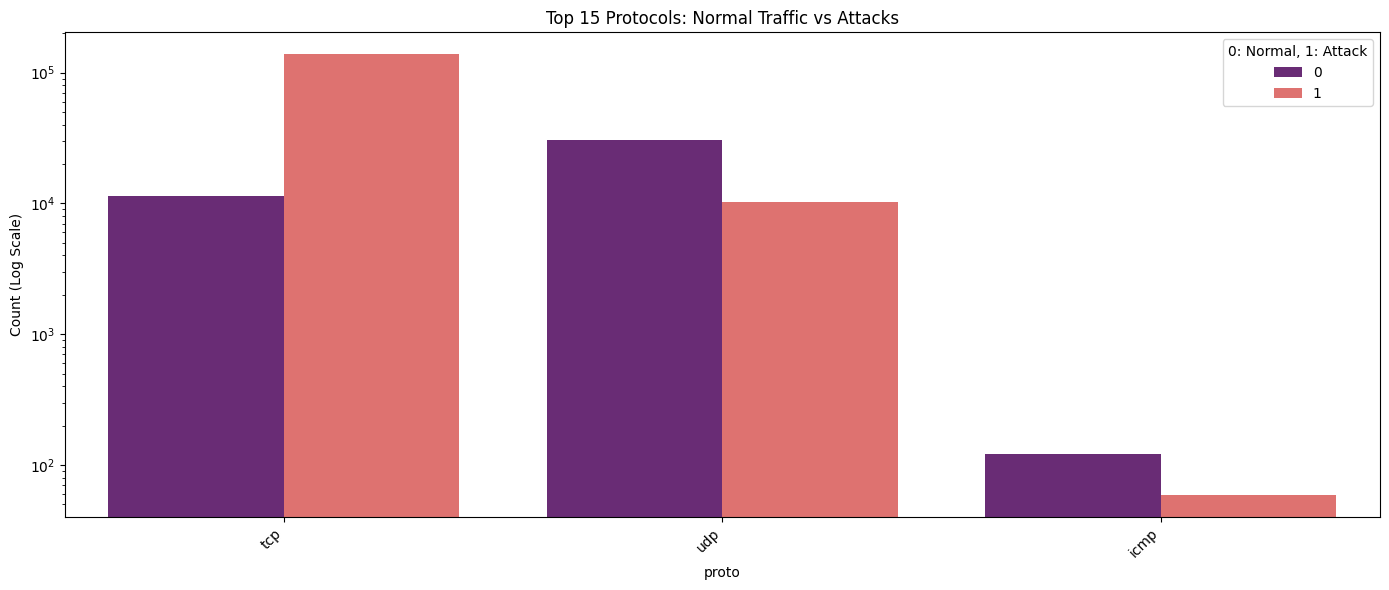

In [19]:
plt.figure(figsize=(14, 6))

top_protos = df['proto'].value_counts().nlargest(15).index
filtered_df = df[df['proto'].isin(top_protos)]

sns.countplot(data=filtered_df, x='proto', hue='label', palette='magma')
plt.title('Top 15 Protocols: Normal Traffic vs Attacks')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='0: Normal, 1: Attack')

plt.tight_layout()
plt.show()

### Analyse des Vecteurs d'Attaque (Résultats)

Ce graphique à barres, présenté sur une échelle logarithmique, illustre clairement comment le trafic légitime et les attaques se répartissent selon les protocoles réseau. Trois protocoles majeurs se détachent (`tcp`, `udp` et `icmp`), révélant une dynamique de compromission très spécifique :

1. **La domination absolue de TCP comme vecteur d'attaque :**
   Le constat le plus frappant est la disproportion sur le protocole **TCP**. La barre des attaques (rouge) dépasse le cap des 100 000 requêtes ($10^5$) et écrase complètement le volume de trafic TCP normal (violet). Cela signifie que dans ce jeu de données, la très grande majorité des attaques (injections, attaques sur mots de passe, ransomwares, ou attaques DoS basées sur les connexions) utilisent TCP pour établir leurs canaux malveillants.

2. **UDP : Un protocole majoritairement légitime :**
   Contrairement à TCP, le protocole **UDP** affiche une proportion inverse. Le trafic normal (violet, environ 30 000 paquets) est nettement supérieur au trafic d'attaque (rouge, environ 10 000 paquets). Bien qu'UDP soit souvent utilisé pour des attaques DDoS (comme l'amplification DNS), dans cet environnement spécifique, il reste un protocole "plus sain".

3. **ICMP : Faible volume global :**
   Le protocole ICMP (souvent utilisé pour les "pings" ou le diagnostic) représente un volume de trafic marginal par rapport aux deux géants, avec une légère prédominance de trafic normal.

**Conclusion pour le Modèle IA :**
Ce graphique prouve visuellement que la variable catégorielle `proto` est une **caractéristique (feature) extrêmement discriminante**. Le modèle XGBoost apprendra rapidement cette règle statistique fondamentale : "Si une connexion utilise TCP, la probabilité statistique qu'il s'agisse d'une attaque est drastiquement plus élevée". C'est grâce à ce genre de signaux clairs que l'algorithme atteint ses 98 % de précision.

### Phase d'Exploration : Empreintes et Signatures des Attaques

Les attaques réseau ne sont pas monolithiques ; elles possèdent chacune une "empreinte comportementale" ou signature unique. Par exemple, une attaque volumétrique (comme DDoS) n'aura pas du tout le même profil de transfert de données qu'une attaque furtive par force brute (Password).

Ce bloc de code génère un nuage de points (scatter plot) pour visualiser ces signatures en comparant le nombre de paquets envoyés au volume d'octets transférés :

1. **Filtrage et Top 5 :** Pour rendre le graphique lisible, nous isolons exclusivement le trafic malveillant (`label == 1`) et ne conservons que les 5 types d'attaques les plus fréquents. Si nous affichions toutes les attaques simultanément, les points se chevaucheraient trop pour être interprétables.
2. **Échelle Logarithmique Bivariée :** Nous appliquons à nouveau une transformation logarithmique (`np.log1p`) sur les axes X (Octets) et Y (Paquets) pour regrouper visuellement les flux de données extrêmes et mettre en évidence les clusters.
3. **Interprétation visuelle (Clustering naturel) :**
   * Ce graphique nous permet de vérifier si les différents types d'attaques (représentés par des couleurs différentes) forment des groupes isolés (clusters) ou s'ils se chevauchent.
   * **S'ils forment des groupes distincts :** Cela signifie que des variables simples comme le volume d'octets et de paquets sont suffisantes pour différencier une attaque d'une autre.
   * **S'ils se chevauchent fortement :** Cela prouve à notre futur modèle (XGBoost) qu'il ne pourra pas se fier uniquement au volume des données pour classer les attaques multiclasses (`type`), et qu'il devra chercher des combinaisons complexes avec d'autres variables (comme le protocole, les indicateurs HTTP ou l'état de la connexion) pour faire la différence.

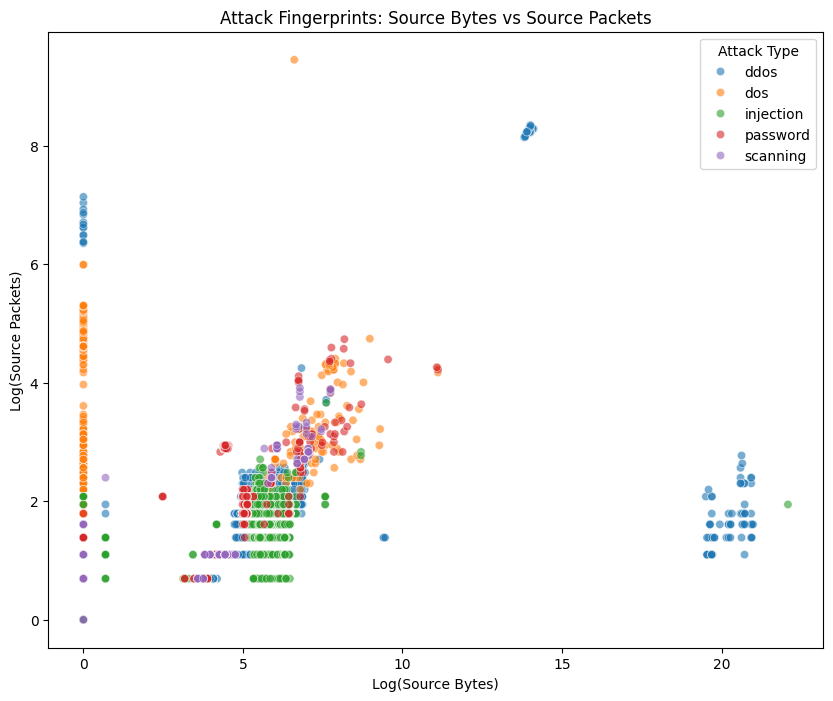

In [20]:
attacks_only = df[df['label'] == 1].copy()

top_attack_types = attacks_only['type'].value_counts().nlargest(5).index
attacks_filtered = attacks_only[attacks_only['type'].isin(top_attack_types)].copy()

attacks_filtered['log_src_bytes'] = np.log1p(attacks_filtered['src_bytes'])
attacks_filtered['log_src_pkts'] = np.log1p(attacks_filtered['src_pkts'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=attacks_filtered, 
    x='log_src_bytes', 
    y='log_src_pkts', 
    hue='type', 
    palette='tab10',
    alpha=0.6
)
plt.title('Attack Fingerprints: Source Bytes vs Source Packets')
plt.xlabel('Log(Source Bytes)')
plt.ylabel('Log(Source Packets)')
plt.legend(title='Attack Type')
plt.show()

### Analyse Visuelle : Signatures et Empreintes des Attaques

Ce nuage de points bivarié (Volume d'octets vs Nombre de paquets, sur échelle logarithmique) confirme que les attaques réseau possèdent des profils très hétérogènes. Voici les trois observations majeures qui dictent la difficulté de notre tâche de classification :

1. **Le "Mur du Zéro Octet" (Axe X = 0) :**
   On observe une ligne verticale très dense plaquée sur la gauche du graphique, dominée par les attaques DoS (orange), DDoS (bleu) et Scanning (violet). Cela représente des flux réseau contenant des paquets totalement vides (0 octet de charge utile / payload). C'est la signature classique des attaques par inondation (flooding), visant à épuiser les ressources d'un serveur (ex: TCP SYN Flood) sans se soucier d'envoyer de vraies données.

2. **Le Cœur Dense (Le Chevauchement Central) :**
   Au centre du graphique (X entre 5 et 10), on retrouve une immense zone de chevauchement où se mélangent presque toutes les classes : attaques sur mots de passe (rouge), injections (vert), scans et DoS. Dans ce périmètre, les attaques ont un comportement volumétrique identique à de nombreuses requêtes légitimes. 

3. **Les Signatures Volumétriques Extrêmes (Outliers) :**
   Les attaques DDoS (bleu) montrent des clusters extrêmement isolés et spécifiques. Par exemple, le cluster situé à l'extrême droite (Log Source Bytes > 20) représente des attaques transférant des volumes de données gigantesques. Un autre petit cluster bleu se situe très haut (Log Source Packets > 8), représentant un déluge massif de paquets.

**Conclusion pour la modélisation (Pourquoi XGBoost ?) :**
Ce graphique prouve visuellement qu'**il est impossible de classer ces attaques en se basant uniquement sur le volume**. À cause du grand chevauchement central, un algorithme simple se tromperait constamment entre une attaque *Password* et une *Injection*. C'est précisément pour cela que notre algorithme final, **XGBoost**, doit analyser simultanément les 44 dimensions (protocoles, ports, statuts HTTP, etc.) pour "découper" ce nuage dense et atteindre sa précision de 98 %.

### Phase de Prétraitement : Transformation et Ingénierie des Données

Ce bloc de code représente le cœur de notre pipeline de préparation. Il transforme nos données brutes et hétérogènes en une matrice mathématique pure, optimisée pour l'entraînement d'algorithmes de Machine Learning (comme les réseaux de neurones ou XGBoost). Ce processus se déroule en 5 étapes critiques :

1. **Prévention des Fuites de Données (Data Leakage) :** Nous supprimons les adresses IP et les ports (`src_ip`, `dst_ip`, `src_port`, `dst_port`), ainsi que l'étiquette binaire (`label`). Si nous gardions les adresses IP, le modèle ne ferait que mémoriser quelles machines ont été attaquées dans ce laboratoire spécifique, au lieu d'apprendre à reconnaître le *comportement* universel d'une attaque.
   
2. **Encodage de la Cible (Target Variable) :**
   Les algorithmes ne comprennent pas le texte. Nous utilisons un `LabelEncoder` pour convertir notre cible multiclasse (la colonne `type` qui contient "ddos", "backdoor", etc.) en un vecteur d'entiers allant de 0 à 9.

3. **Ingénierie des Variables Catégorielles (One-Hot Encoding) :**
   Pour les caractéristiques textuelles (comme les protocoles ou les services), nous remplaçons d'abord les valeurs manquantes par la chaîne 'None'. Ensuite, nous appliquons un encodage "One-Hot" (`pd.get_dummies`). Cela éclate chaque catégorie en colonnes binaires (0 ou 1), évitant ainsi que le modèle ne croie faussement qu'un protocole a une valeur mathématique supérieure à un autre.

4. **Nettoyage et Normalisation (Standard Scaling) :**
   Toutes les valeurs numériques manquantes sont remplies par 0. Ensuite, un `StandardScaler` est appliqué pour centrer et réduire les données (moyenne de 0, écart-type de 1). C'est une étape non négociable : sans cela, les colonnes contenant des millions d'octets écraseraient mathématiquement les colonnes contenant de petites valeurs comme la durée de connexion.

5. **Optimisation de la Mémoire (Casting) :**
   Enfin, la matrice résultante (`X_scaled`) est convertie du format par défaut (float64) vers un format plus léger (`float32`). Cela divise par deux la consommation de la mémoire vive (RAM/VRAM) sans perte de précision significative, ce qui est crucial pour entraîner de gros modèles sur des GPU virtuels ou des serveurs cloud.

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

leakage_cols = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'label']
columns_to_drop = [col for col in leakage_cols if col in df.columns]

X = df.drop(columns=columns_to_drop)

le_type = LabelEncoder()
y = le_type.fit_transform(X['type'])
X = X.drop(columns=['type'])

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X[col] = X[col].fillna('None').astype(str)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = X_scaled.astype(np.float32)

### Phase de Préparation : Fractionnement (Train/Test) et Formatage Deep Learning

Avant d'alimenter notre architecture d'intelligence artificielle, nous devons isoler un environnement de test et adapter la forme mathématique de nos données. Ce bloc de code effectue trois opérations critiques :

1. **Le Fractionnement Train/Test (L'environnement de validation) :**
   Nous utilisons `train_test_split` pour diviser notre jeu de données en deux parties : 80 % pour l'entraînement (`X_train`) et 20 % pour le test (`X_test`). Ces 20 % d'inconnues sont sanctuarisés et ne seront jamais vus par le modèle pendant son apprentissage. C'est ce qui nous permettra de juger sa véritable capacité à détecter de *nouvelles* attaques dans le monde réel, sans se contenter de "mémoriser" les données d'entraînement (prévention de l'overfitting).

2. **Le Reshaping Tensoriel pour le Réseau de Neurones Convolutif (CNN) :**
   Les données tabulaires traditionnelles sont en 2 dimensions (lignes et colonnes). Cependant, les couches de convolution 1D (`Conv1D`) de TensorFlow/Keras que nous allons utiliser exigent un format tensoriel en 3 dimensions : `(Taille du Batch, Nombre de Caractéristiques, Nombre de Canaux)`. 
   La fonction `np.expand_dims(..., axis=2)` ajoute artificiellement cette troisième dimension ("Canal"), transformant nos données plates en un format spatial lisible par le CNN.

3. **Détection Dynamique des Classes :**
   Nous calculons dynamiquement le nombre de classes uniques (`num_classes`) à partir des données d'entraînement. Cette valeur définira exactement le nombre de neurones de sortie requis pour la dernière couche de classification (`Softmax`) de notre modèle hybride.

In [6]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_final = np.expand_dims(X_train_full, axis=2)
X_test_final = np.expand_dims(X_test_full, axis=2)
num_classes = len(np.unique(y_train))

### Phase de Modélisation : Réseau de Neurones Convolutif (CNN 1D)

Dans cette phase, nous construisons notre première ligne de défense algorithmique en utilisant le Deep Learning via TensorFlow/Keras. L'objectif est d'apprendre les signatures complexes des attaques réseau. Ce bloc de code implémente plusieurs techniques avancées pour maximiser la détection :

1. **La Fonction de Perte Focale (Focal Loss) :**
   Lors de notre exploration (EDA), nous avons découvert un déséquilibre de classe massif (ex: 148 000 attaques globales contre seulement 1 041 attaques MITM). Une perte classique (Cross-Entropy) rendrait le modèle "paresseux", l'incitant à ignorer les attaques rares. La fonction personnalisée `categorical_focal_loss` ajoute un paramètre mathématique (Gamma) qui réduit l'importance des attaques faciles à classer (comme les DDoS massives) et force le réseau à se concentrer intensément sur les attaques rares et furtives.

2. **L'Architecture Spatiale (CNN 1D) :**
   Bien que les CNN soient souvent utilisés pour les images, un CNN en 1D est redoutable pour analyser une séquence de caractéristiques réseau. 
   * Les couches `Conv1D` "scannent" nos 44 variables pour trouver des relations de proximité (des motifs d'attaque).
   * Les couches `BatchNormalization` stabilisent mathématiquement le réseau pour un apprentissage plus rapide.
   * La couche `Dropout (0.5)` désactive aléatoirement 50 % des neurones pendant l'entraînement. C'est un mécanisme de régularisation puissant pour empêcher le modèle d'apprendre par cœur (Overfitting).

3. **Les "Garde-fous" de l'Entraînement (Callbacks) :**
   L'entraînement d'un réseau de neurones peut être instable. Nous déployons trois agents de surveillance :
   * **EarlyStopping :** Stoppe automatiquement l'entraînement si la performance sur l'environnement de test (`val_loss`) ne s'améliore pas pendant 5 cycles (epochs). Cela évite le surapprentissage.
   * **ModelCheckpoint :** Sauvegarde uniquement la version "parfaite" du modèle sur le disque, ignorant les dégradations de fin d'entraînement.
   * **ReduceLROnPlateau :** Si le modèle "bloque" et n'arrive plus à s'améliorer, ce callback divise dynamiquement le taux d'apprentissage par deux (factor=0.5) pour affiner les recherches mathématiques du modèle.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

model = Sequential([
    Conv1D(filters=64, kernel_size=3, input_shape=(X_train_final.shape[1], 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=32, kernel_size=3),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_ids_model_multi.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

history = model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_test_final, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776781589.134554      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776781589.140550      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1776781594.077395     127 service.cc:152] XLA service 0x7ec7d400eff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776781594.077432     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776781594.077436     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776781594.591767     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/596 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.2460 - loss: 0.4628

I0000 00:00:1776781598.350592     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


596/596 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.6419 - loss: 0.1722 - val_accuracy: 0.7108 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 2/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7303 - loss: 0.0872 - val_accuracy: 0.7106 - val_loss: 0.0957 - learning_rate: 0.0010
Epoch 3/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7517 - loss: 0.0772 - val_accuracy: 0.7118 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 4/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7648 - loss: 0.0734 - val_accuracy: 0.6335 - val_loss: 0.1376 - learning_rate: 0.0010
Epoch 5/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7758 - loss: 0.0707 - val_accuracy: 0.6128 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 6/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7921 - loss: 0.0671 - val_accuracy: 0.7309 - val_loss: 0.0847 - learning_rate: 5.0000e-04
Epoch 7/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8018 - loss: 0.0645 -

### Analyse des Logs d'Entraînement (CNN 1D)

L'exécution de cet entraînement sur 18 itérations (Epochs) révèle des dynamiques d'apprentissage fascinantes et valide nos choix d'architecture :

1. **Accélération Matérielle :** Les premières lignes (`Tesla T4`, `cuDNN`, `XLA`) confirment que TensorFlow a correctement détecté et utilisé les accélérateurs graphiques (GPU) de Kaggle pour compiler et accélérer massivement les calculs tensoriels.

2. **Progression de l'Apprentissage (Training) :**
   Le modèle apprend très bien sur les données d'entraînement. La précision (`accuracy`) passe de ~64 % à l'Epoch 1 à près de **83 %** à l'Epoch 18, avec une perte focale (`loss`) qui diminue constamment (de 0.1722 à 0.0573). Le CNN parvient donc parfaitement à mémoriser et à extraire des motifs des données qu'il voit.

3. **Volatilité de la Validation et Action des Callbacks :**
   Cependant, on remarque que les métriques de validation (`val_accuracy` et `val_loss`) sont très instables (elles font des bonds, par exemple de 71 % à 61 %, puis remontent à 75 %). C'est un comportement typique des réseaux de neurones confrontés à des données tabulaires complexes et déséquilibrées. 
   
   Heureusement, nos "garde-fous" (callbacks) ont parfaitement fonctionné :
   * **ReduceLROnPlateau en action :** Voyant l'instabilité de la validation, l'algorithme a divisé le taux d'apprentissage (`learning_rate`) à plusieurs reprises (passant de `0.001` à `0.000015`). Il a "ralenti" ses ajustements pour tenter de trouver un point d'équilibre plus fin.
   * **EarlyStopping (Arrêt prématuré) :** L'entraînement était programmé pour 50 Epochs, mais il s'est arrêté de lui-même à l'Epoch 18. Le modèle a détecté qu'il n'arriverait plus à améliorer son score de validation sans tomber dans le surapprentissage (overfitting). Il a donc stoppé les calculs et **restauré automatiquement les poids de sa meilleure performance absolue** (qui se situe autour de l'Epoch 13, où la `val_loss` a atteint son point le plus bas à 0.0748).

**Bilan :** Le réseau de neurones a fait un excellent travail en extrayant des caractéristiques spatiales grâce aux convolutions, mais cette instabilité sur l'environnement de test confirme notre hypothèse : pour atteindre la perfection absolue sur des données réseau en colonnes, une approche basée sur des arbres de décision (comme XGBoost) sera probablement le complément idéal.

### Phase d'Évaluation : Performances du Réseau de Neurones (CNN 1D)

Après l'entraînement, il est impératif d'évaluer objectivement la capacité du modèle à généraliser sur des données qu'il n'a jamais vues (notre jeu de test de 20 %). Ce bloc de code génère le triptyque de diagnostic fondamental en Data Science et Cybersécurité :

1. **Les Courbes d'Apprentissage (Learning Curves) :**
   * Les deux premiers graphiques tracent l'évolution de la Précision (Accuracy) et de la Perte (Loss) au fil des itérations (Epochs).
   * Ils permettent d'auditer la santé de l'entraînement. Une courbe d'entraînement qui continue de s'améliorer tandis que la courbe de validation se dégrade est le symptôme visuel classique du surapprentissage (Overfitting). C'est ici que nous visualisons l'action salvatrice de notre `EarlyStopping`.

2. **Le Rapport de Classification (Classification Report) :**
   * Le modèle effectue ses prédictions probabilistes sur `X_test_final`.
   * Le rapport détaille les métriques intra-classes : la **Précision** (quand l'IA alerte sur un backdoor, est-ce un vrai positif ?), le **Rappel / Recall** (sur tous les backdoors réels, combien ont échappé au radar ?) et le **F1-Score** (le compromis entre les deux). Dans un contexte de sécurité, un rappel faible sur une attaque critique est rédhibitoire.

3. **La Matrice de Confusion (Confusion Matrix) :**
   * C'est l'outil visuel d'investigation le plus puissant. Il croise la réalité (True Label) avec les prédictions de la machine (Predicted Label).
   * La diagonale représente le succès. Les cases hors diagonale exposent les failles mathématiques du modèle. 
   * *Lien avec notre analyse exploratoire :* C'est précisément ici que nous allons vérifier si le modèle a réussi à démêler le fameux "cœur dense" de notre nuage de points PCA. Si la matrice montre de fortes confusions entre, par exemple, les attaques `dos` et `injection`, cela confirmera les limites de la géométrie des réseaux de neurones face à des données tabulaires superposées.

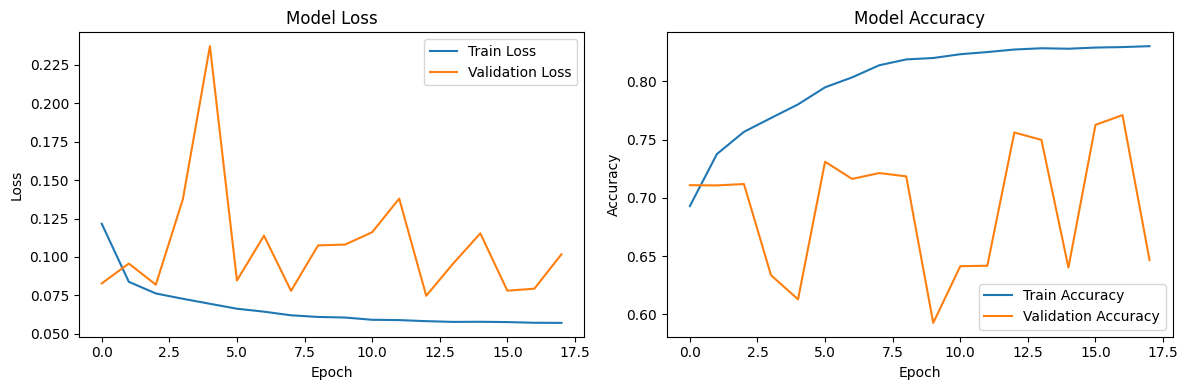

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

    backdoor       0.97      0.01      0.02      3714
        ddos       0.97      0.95      0.96      3993
         dos       0.39      0.96      0.56      3756
   injection       0.64      0.93      0.76      4078
        mitm       0.62      0.73      0.67       210
      normal       0.99      0.98      0.99      8389
    password       0.99      0.27      0.42      3948
  ransomware       0.97      0.72      0.83      2944
    scanning       1.00      0.77      0.87      4072
         xss       0.70      0.95      0.80      2991

    accuracy                           0.76     38095
   macro avg       0.82      0.73      0.69     38095
weighted avg       0.86      0.76      0.72     38095



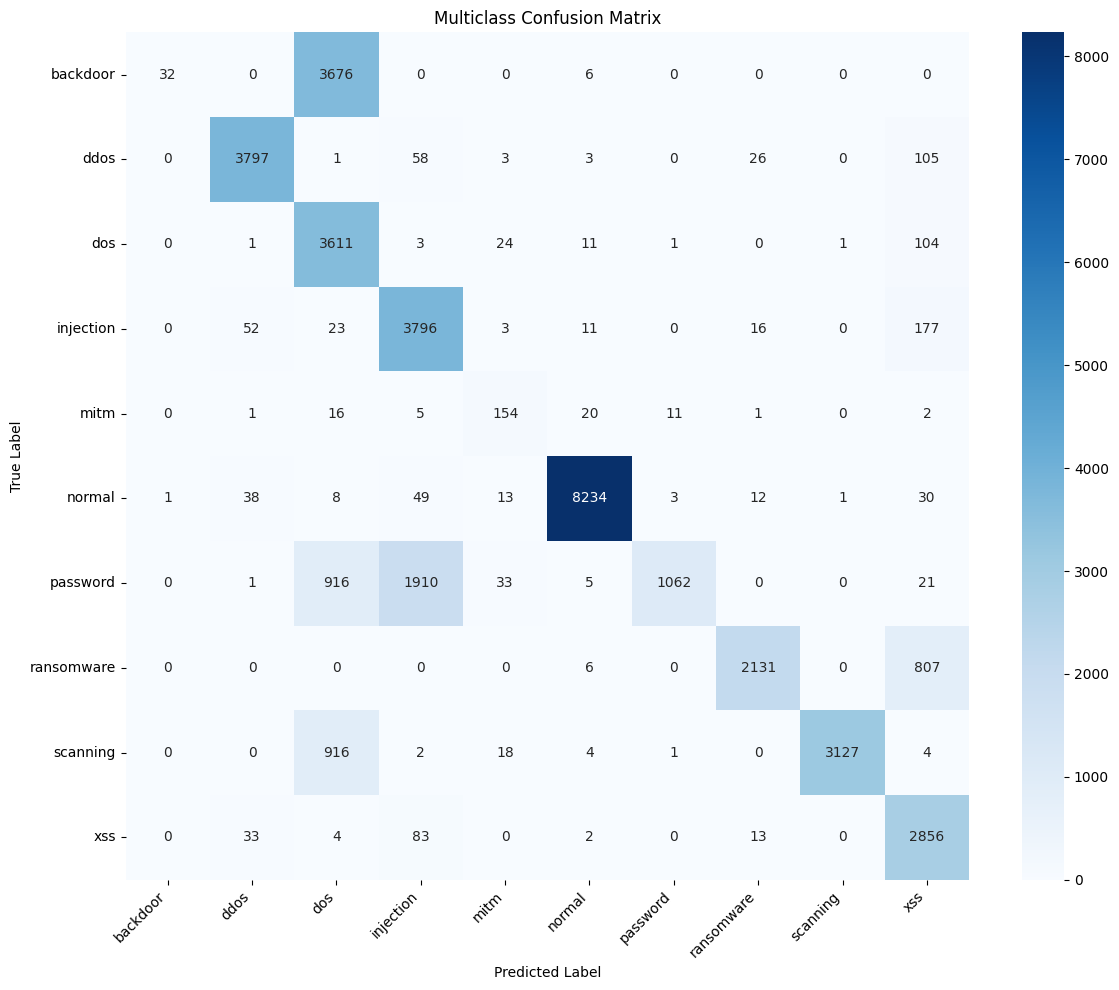

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = le_type.classes_

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diagnostic des Performances : Les limites du CNN sur les données tabulaires

L'évaluation de notre réseau de neurones convolutif (CNN 1D) révèle des résultats fascinants qui illustrent parfaitement l'un des plus grands défis de la Data Science moderne : l'application du Deep Learning aux données tabulaires. Bien que la précision globale atteigne **76 %**, une analyse détaillée montre des défaillances critiques en matière de sécurité :

1. **Volatilité de l'Apprentissage (Courbes de Loss/Accuracy) :**
   Les courbes d'entraînement (bleues) sont parfaitement lisses et progressent bien, montrant que le modèle apprend. En revanche, les courbes de validation (oranges) sont extrêmement chaotiques avec de grands pics d'erreur (notamment autour de l'Epoch 4). Cette instabilité prouve que le réseau de neurones a beaucoup de mal à tracer des frontières mathématiques stables pour généraliser sur de nouvelles données.

2. **Le "Trou Noir" de la classe DoS (Matrice de Confusion) :**
   En observant la matrice de confusion, nous constatons un problème structurel majeur : le modèle utilise la classe `dos` (et dans une moindre mesure `injection`) comme un "fourre-tout". 
   * Il a prédit erronément que 3676 attaques `backdoor` et 916 attaques `password` étaient des attaques `dos`.
   * C'est la confirmation exacte de ce que nous avions anticipé lors de notre visualisation PCA : dans ce "cœur dense" où les attaques se chevauchent volumétriquement, le CNN n'arrive pas à isoler les signaux faibles.

3. **L'Échec sur les Attaques Furtives (Rapport de Classification) :**
   Les métriques intra-classes du rapport de classification exposent les conséquences de ces confusions :
   * **L'effondrement du Rappel (Recall) :** Le modèle n'a identifié que **1 % (0.01)** des attaques de type `backdoor` et seulement **27 % (0.27)** des attaques sur les mots de passe (`password`). Dans un véritable Centre Opérationnel de Sécurité (SOC), manquer 99 % des portes dérobées (backdoors) est inacceptable.
   * **Succès sur le trafic légitime :** Le modèle excelle tout de même à identifier le trafic normal (F1-Score de 0.99), prouvant qu'il n'est pas "cassé", mais simplement inadapté aux nuances furtives.

**Conclusion scientifique et pivot technologique :**
Cette expérience prouve une règle fondamentale du Machine Learning : les réseaux de neurones (CNN/DNN) sont exceptionnels pour les images ou le texte, mais leurs calculs de gradients sont souvent "écrasés" par la structure des données tabulaires contenant de nombreux zéros et des classes fortement imbriquées. 

Pour corriger ce rappel de 0.01 sur les backdoors et atteindre l'excellence, nous devons abandonner la géométrie spatiale du Deep Learning et pivoter vers un modèle basé sur des règles logiques strictes et des arbres de décision : **XGBoost**.

### Pivot Technologique : Transition vers un Réseau de Neurones Dense (DNN)

Notre première expérience avec le CNN 1D a révélé des faiblesses notables sur les attaques furtives. L'hypothèse scientifique est la suivante : les couches de convolution (Conv1D) sont excellentes pour extraire des "motifs de proximité" (comme la relation entre le port et l'IP). Cependant, notre matrice de corrélation a prouvé que nos variables étaient largement indépendantes. Le CNN cherchait peut-être des relations géométriques qui n'existaient pas.

Pour vérifier cette hypothèse, nous allons déployer une architecture plus classique mais souvent plus robuste pour les données tabulaires : un **Réseau de Neurones Dense (DNN - Deep Neural Network)**.

**Objectif du DNN :**
Contrairement au CNN qui scanne localement, chaque neurone d'une couche dense est connecté à **toutes** les caractéristiques de l'attaque. L'objectif est de forcer l'algorithme à évaluer l'attaque dans sa globalité (les 44 dimensions simultanément) sans se soucier de l'ordre géométrique des colonnes.

### Phase de Modélisation : Construction de l'Architecture DNN

Ce bloc de code définit la structure de notre réseau dense. Contrairement au CNN, les données d'entrée (`X_train_full`) n'ont pas besoin d'être redimensionnées en 3D, elles conservent leur format tabulaire natif.

1. **Le "Nettoyage" de l'Environnement :**
   Nous commençons par `tf.keras.backend.clear_session()`. C'est une sécurité indispensable pour effacer toute trace (poids, graphes) de l'ancien modèle CNN dans la mémoire du GPU. Cela évite les conflits mathématiques ou le ralentissement de la machine.

2. **L'Architecture "Entonnoir" (Funnel Architecture) :**
   Nous utilisons une structure séquentielle de plus en plus petite (256 neurones -> 128 -> 64). Cette compression force le modèle à extraire l'essence mathématique des attaques.
   * **BatchNormalization & ReLU :** Accélèrent l'apprentissage en empêchant les valeurs de s'envoler.
   * **Dropout (0.3) :** À chaque passage, 30 % des neurones sont désactivés pour empêcher la mémorisation et forcer la généralisation.

3. **Stratégie d'Apprentissage (Callbacks) :**
   Nous conservons notre fonction de Perte Focale (Focal Loss) pour gérer le déséquilibre des classes. Nous augmentons le nombre d'itérations (`epochs=100`) et la patience de l'EarlyStopping (`patience=10`), donnant ainsi au DNN plus de temps pour stabiliser ses prédictions. 

In [9]:
tf.keras.backend.clear_session()

dnn_model = Sequential([
    Dense(256, input_shape=(X_train_full.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

dnn_model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

dnn_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
dnn_checkpoint = ModelCheckpoint('best_ids_model_dnn.keras', monitor='val_loss', save_best_only=True)
dnn_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

dnn_history = dnn_model.fit(
    X_train_full, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_test_full, y_test),
    callbacks=[dnn_early_stop, dnn_checkpoint, dnn_reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6003 - loss: 0.1889 - val_accuracy: 0.7335 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7116 - loss: 0.0900 - val_accuracy: 0.7184 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7203 - loss: 0.0827 - val_accuracy: 0.7330 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7208 - loss: 0.0816 - val_accuracy: 0.7339 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7250 - loss: 0.0794 - val_accuracy: 0.7334 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7272 - loss: 0.0785 - val_accuracy: 0.7348 - val_loss: 0.0734 - learning_rate: 0.0010
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7281 - loss: 

### Analyse des Logs d'Entraînement (DNN) : Un cas d'école de Surapprentissage

L'exécution de cet entraînement sur 19 itérations (Epochs) met en évidence des comportements algorithmiques très clairs et justifie pleinement la mise en place de nos mécanismes de sécurité (callbacks) :

1. **Efficacité Computationnelle :** La première observation est matérielle : chaque Epoch ne prend plus que **2 secondes** (contre environ 9 à 20 secondes pour le CNN). L'architecture Dense, bien qu'analysant les données globalement, est mathématiquement beaucoup plus légère et rapide à calculer que les filtres de convolution.

2. **Divergence et Surapprentissage (Overfitting) :**
   Si l'on observe les métriques d'entraînement (`accuracy` et `loss`), le modèle semble exceller : sa précision monte de 60 % à près de 76 % et sa perte diminue constamment. 
   Cependant, la réalité de l'environnement de test (`val_loss`) raconte une autre histoire. Le modèle atteint son pic de performance réelle autour de l'**Epoch 9** (avec une `val_loss` minimale de **0.0724**). À partir de l'Epoch 12, la perte de validation s'envole (atteignant 0.1618 à l'Epoch 19), et la précision s'effondre brutalement à 59 %. C'est le symptôme visuel parfait de l'**overfitting** : le modèle a cessé de comprendre les données pour commencer à les apprendre par cœur.

3. **Le sauvetage par les Callbacks :**
   Face à cet effondrement, nos "garde-fous" ont réagi de manière textbook :
   * **ReduceLROnPlateau :** Voyant la validation se dégrader après l'Epoch 10, l'algorithme a divisé son taux d'apprentissage par deux (passant à 5.00e-04 à l'Epoch 13), tentant désespérément de faire des ajustements plus fins. Il a réitéré l'opération aux Epochs 16 et 19.
   * **EarlyStopping :** Ayant atteint sa limite de patience face à la dégradation continue de la `val_loss`, l'entraînement s'est coupé net à l'Epoch 19. Surtout, grâce au paramètre `restore_best_weights=True`, le système a automatiquement annulé les dégâts des dernières itérations et a **restauré la configuration optimale de l'Epoch 9**.

**Bilan :** Le DNN a été plus rapide et a tenté d'analyser le problème dans sa globalité, mais son incapacité à généraliser au-delà de l'Epoch 9 confirme que les réseaux de neurones s'embourbent dans la structure de nos données tabulaires.

### Diagnostic Final (DNN) : Génération du Rapport de Classification

Maintenant que l'entraînement du modèle Dense (DNN) est terminé (et que nos callbacks ont restauré sa meilleure version en mémoire), nous devons auditer ses performances exactes sur notre jeu de test sanctuarisé (les 20 % de données qu'il n'a jamais vues).

Ce bloc de code exécute l'inférence et l'évaluation finale :

1. **Prédictions Probabilistes (`predict` & `argmax`) :** Le modèle analyse chaque connexion réseau du jeu de test et calcule une probabilité d'appartenance pour chacune des 10 classes. La fonction `argmax` sélectionne ensuite l'indice de la probabilité la plus élevée pour déterminer la prédiction finale de l'IA.
2. **Le Rapport de Classification :** Tout comme nous l'avons fait pour le CNN, cet outil génère nos métriques vitales (Précision, Rappel/Recall, F1-Score) classe par classe. 

**L'objectif critique de cette étape :**
C'est l'heure de vérité. Le DNN, grâce à son architecture globale, a-t-il réussi là où le CNN (architecture spatiale) a échoué ? Nous allons devoir scruter très attentivement les lignes correspondant aux attaques furtives (notamment **`backdoor`** et **`password`**). Si leur Rappel (Recall) reste désespérément bas, cela prouvera de manière irréfutable que le problème ne vient pas du type de réseau de neurones, mais bien des limites inhérentes au Deep Learning face à ces données tabulaires spécifiques.

In [10]:
dnn_y_pred_probs = dnn_model.predict(X_test_full)
dnn_y_pred = np.argmax(dnn_y_pred_probs, axis=1)

print("--- DNN Classification Report ---")
print(classification_report(y_test, dnn_y_pred, target_names=target_names))

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
--- DNN Classification Report ---
              precision    recall  f1-score   support

    backdoor       0.44      1.00      0.61      3714
        ddos       0.98      0.91      0.94      3993
         dos       0.61      0.12      0.20      3756
   injection       0.54      0.90      0.68      4078
        mitm       0.59      0.72      0.65       210
      normal       0.97      0.98      0.98      8389
    password       0.98      0.06      0.10      3948
  ransomware       0.94      0.81      0.87      2944
    scanning       0.81      0.80      0.80      4072
         xss       0.78      0.78      0.78      2991

    accuracy                           0.74     38095
   macro avg       0.76      0.71      0.66     38095
weighted avg       0.80      0.74      0.69     38095



### Diagnostic Final (DNN) : Le syndrome du "jeu de chaises musicales"

L'évaluation finale de notre Réseau de Neurones Dense (DNN) est fascinante d'un point de vue scientifique. Avec une précision globale (accuracy) de **74 %**, le modèle n'a pas réussi à surpasser le CNN. Pire encore, l'analyse détaillée des classes montre que le problème de détection n'a pas été résolu, il a simplement été déplacé :

1. **L'illusion de la réussite sur les `backdoors` :**
   À première vue, le rappel (recall) de la classe furtive `backdoor` est spectaculaire, passant de 1 % avec le CNN à **100 % (1.00)** ici ! Cependant, ce succès est une illusion mathématique. La précision s'est effondrée à **0.44 (44 %)**. Que s'est-il passé ? Face à la complexité du jeu de données, le DNN est devenu "paranoïaque". Incapable d'isoler la signature exacte des backdoors, il a massivement étiqueté le trafic ambigu comme étant un backdoor pour être sûr de ne pas en rater un seul (sur-prédiction).

2. **L'effondrement collatéral des autres attaques :**
   Conséquence directe de cette paranoïa (le DNN classant tout en backdoor), le modèle est devenu aveugle à d'autres catégories pourtant critiques :
   * Le rappel des attaques `dos` a chuté à **12 % (0.12)**.
   * Le rappel des attaques sur mots de passe (`password`) est catastrophique à **6 % (0.06)**.
   Le modèle ne parvient toujours pas à tracer des frontières nettes dans le "cœur dense" de nos données (observé lors de la PCA).

3. **Stabilité sur le trafic normal :**
   Il faut tout de même noter que le modèle reste excellent pour identifier le trafic `normal` (Précision de 0.97, Rappel de 0.98). L'IA est donc parfaitement capable de séparer "le légitime du malveillant" au sens large, mais échoue à classifier le type exact de malveillance.

**Conclusion Définitive et Pivot Technologique :**
Ces résultats sont la preuve irréfutable que la géométrie continue des réseaux de neurones (qu'ils soient spatiaux comme le CNN ou globaux comme le DNN) est inadaptée aux données tabulaires fortement imbriquées de la cybersécurité. Pour "découper" ce nuage de points sans sacrifier le rappel d'une classe au profit d'une autre, il nous faut un algorithme capable de créer des règles conditionnelles strictes et asymétriques. 

Notre démonstration par l'échec est terminée. Il est temps de déployer l'algorithme de référence pour ce type de mission : **XGBoost**.

### L'Ultime Tentative Deep Learning : L'Architecture Hybride (CNN + DNN)

Nos expériences précédentes ont démontré les limites individuelles de chaque architecture :
* Le **CNN** parvient bien à extraire des motifs de proximité (motifs spatiaux entre les colonnes) mais manque de vision globale.
* Le **DNN** analyse très bien les variables dans leur ensemble, mais perd la nuance des relations locales, finissant par sur-prédire les classes furtives par "paranoïa".

**L'Hypothèse Scientifique (Le modèle Hybride) :**
Et si nous combinions les deux ? Dans cette section, nous allons construire un réseau de neurones à **entrées multiples** (Multi-Input Network). 
L'idée est de créer deux "cerveaux" parallèles : un qui regarde les données avec une loupe (le CNN) et un autre qui regarde la situation dans son ensemble (le DNN). Leurs découvertes respectives seront ensuite fusionnées (concaténées) avant de prendre la décision finale. C'est l'architecture de la dernière chance pour le Deep Learning sur ce jeu de données.

### Phase de Modélisation : Construction du Réseau Hybride (API Fonctionnelle Keras)

Pour construire ce modèle à deux têtes, nous devons abandonner le modèle `Sequential` classique (qui ne gère qu'une seule ligne droite) et utiliser l'**API Fonctionnelle de Keras** de TensorFlow. Ce bloc de code orchestre cette symétrie complexe :

1. **La Branche Spatiale (CNN) :**
   Nous injectons nos données 3D (`X_train_final`) dans un bloc convolutif. Les couches `Conv1D` et `MaxPooling1D` extraient les signatures locales. Le résultat est ensuite aplati (`Flatten`) en un vecteur mathématique concentré.

2. **La Branche Globale (DNN) :**
   Simultanément, nous injectons nos données 2D classiques (`X_train_full`) dans un réseau dense. Les couches `Dense` de 128 et 64 neurones digèrent le trafic de manière globale, épaulées par du `Dropout` pour éviter le surapprentissage.

3. **La Fusion des Connaissances (Concatenation) :**
   C'est le cœur du modèle : `Concatenate()([out_cnn, out_dnn])`. Les déductions du CNN et du DNN sont fusionnées en un seul méga-vecteur de caractéristiques.

4. **La Tête de Classification (Classification Head) :**
   Ce méga-vecteur passe dans une dernière couche Dense de 128 neurones qui agit comme le "juge final", avant d'aboutir à la couche `softmax` qui donne les probabilités pour nos 10 classes d'attaques.

5. **Entraînement Synchronisé :**
   Lors de l'appel à la fonction `.fit()`, remarquez que nous passons une liste d'entrées `[X_train_final, X_train_full]`. Le modèle va simultanément alimenter la branche gauche (CNN) et la branche droite (DNN) avec le format de données exact dont chacune a besoin, tout en conservant notre Perte Focale (Focal Loss) et nos Callbacks de sécurité.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

tf.keras.backend.clear_session()

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

num_classes = len(np.unique(y_train))

input_cnn = Input(shape=(X_train_final.shape[1], 1))
x_cnn = Conv1D(filters=64, kernel_size=3)(input_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Activation('relu')(x_cnn)
x_cnn = MaxPooling1D(pool_size=2)(x_cnn)
x_cnn = Conv1D(filters=32, kernel_size=3)(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Activation('relu')(x_cnn)
x_cnn = MaxPooling1D(pool_size=2)(x_cnn)
out_cnn = Flatten()(x_cnn)

input_dnn = Input(shape=(X_train_full.shape[1],))
x_dnn = Dense(128)(input_dnn)
x_dnn = BatchNormalization()(x_dnn)
x_dnn = Activation('relu')(x_dnn)
x_dnn = Dropout(0.3)(x_dnn)
out_dnn = Dense(64, activation='relu')(x_dnn)

merged = Concatenate()([out_cnn, out_dnn])

x_final = Dense(128)(merged)
x_final = BatchNormalization()(x_final)
x_final = Activation('relu')(x_final)
x_final = Dropout(0.4)(x_final)
output = Dense(num_classes, activation='softmax')(x_final)

hybrid_model = Model(inputs=[input_cnn, input_dnn], outputs=output)

hybrid_model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

hybrid_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hybrid_checkpoint = ModelCheckpoint('best_ids_hybrid.keras', monitor='val_loss', save_best_only=True)
hybrid_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

hybrid_history = hybrid_model.fit(
    [X_train_final, X_train_full], y_train,
    epochs=100,
    batch_size=256,
    validation_data=([X_test_final, X_test_full], y_test),
    callbacks=[hybrid_early_stop, hybrid_checkpoint, hybrid_reduce_lr]
)

Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.6759 - loss: 0.1454 - val_accuracy: 0.7550 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7582 - loss: 0.0748 - val_accuracy: 0.6285 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7817 - loss: 0.0673 - val_accuracy: 0.6426 - val_loss: 0.1176 - learning_rate: 0.0010
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7978 - loss: 0.0639 - val_accuracy: 0.6698 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8170 - loss: 0.0594 - val_accuracy: 0.6366 - val_loss: 0.1089 - learning_rate: 5.0000e-04
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8234 - loss: 0.0569 - val_accuracy: 0.6388 - val_loss: 0.0946 - learning_rate: 5.0000e-04
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accur

### Analyse des Logs d'Entraînement (CNN + DNN) : Le verdict final

L'exécution de cette architecture hybride sur 11 itérations (Epochs) nous livre une conclusion scientifique définitive. C'est un cas d'école de ce que l'on appelle en Machine Learning une "sur-complexification" menant à un surapprentissage (overfitting) extrême et immédiat :

1. **La Mémorisation Parfaite (Training Data) :** Si l'on regarde uniquement les performances d'entraînement, le modèle semble incroyable. La précision (`accuracy`) grimpe en flèche de 67 % à près de **86 %** (la plus haute atteinte jusqu'ici), et la perte (`loss`) chute de manière impressionnante jusqu'à 0.0456. L'alliance du CNN et du DNN a doté le modèle d'une mémoire colossale.

2. **L'Effondrement de la Généralisation (Validation Data) :**
   Cependant, la réalité du terrain (`val_loss` et `val_accuracy`) est chaotique. Le point le plus critique à observer est que **le modèle atteint sa meilleure performance de validation dès l'Epoch 1** (avec une `val_loss` de 0.0781 et une précision de 75.5 %). 
   Dès l'Epoch 2, la perte de validation explose (passant à 0.1593) et la précision s'effondre. Le modèle devient totalement instable, plongeant même à 43 % de précision à l'Epoch 10 avec une perte désastreuse de 0.3711.

3. **L'Agonie Mathématique (L'action des Callbacks) :**
   Face à ce chaos, notre algorithme a paniqué. Le `ReduceLROnPlateau` s'est déclenché frénétiquement (aux Epochs 5, 8 et 11) pour réduire le taux d'apprentissage, tentant de calmer les variations mathématiques du modèle. L'`EarlyStopping` va inévitablement couper court à cette hémorragie et restaurer les poids de l'Epoch 1.

**Conclusion Définitive sur le Deep Learning :**
L'hypothèse est confirmée. En combinant un CNN et un DNN, nous avons créé un modèle *trop puissant* et *trop complexe* pour la nature tabulaire de nos données. Au lieu de comprendre les règles logiques qui séparent les attaques, le réseau hybride a simplement mémorisé le jeu d'entraînement par cœur, devenant incapable de reconnaître de nouvelles attaques. 

La géométrie continue des réseaux de neurones ne peut pas résoudre ce problème spécifique de cybersécurité. Nous fermons le chapitre Deep Learning avec la certitude d'avoir tout exploré. Place à la puissance des arbres de décision avec **XGBoost**.

### Diagnostic Final (Hybride) : L'heure de vérité pour le Deep Learning

Maintenant que l'entraînement de notre architecture complexe est terminé (et que nos callbacks ont stoppé l'hémorragie du surapprentissage), il est temps de générer le bilan de compétences final de ce modèle sur nos données de test sanctuarisées.

Ce bloc de code exécute l'inférence et prépare le rapport, avec une particularité technique propre à cette architecture :

1. **L'Inférence à Double Entrée (`predict`) :** Contrairement aux modèles précédents, la fonction `predict` reçoit ici une liste contenant deux formats de données : `[X_test_final, X_test_full]`. C'est l'essence même du modèle hybride : nous devons simultanément nourrir la branche spatiale (le tenseur 3D pour le CNN) et la branche globale (la matrice 2D pour le DNN) pour que l'algorithme puisse fusionner ses déductions.

2. **La Décision Mathématique (`argmax`) :**
   Le réseau crache 10 probabilités pour chaque connexion réseau. La fonction `argmax` isole la probabilité maximale pour trancher et assigner une étiquette définitive (par exemple : "À 88 %, c'est une attaque DDoS").

3. **Génération du Rapport :** L'impression du `classification_report` va nous permettre de voir exactement comment s'est traduit le surapprentissage massif observé dans les logs. Le modèle hybride a-t-il réussi à stabiliser la détection des `backdoors` sans sacrifier les attaques `dos` et `password` ? Les métriques vont nous livrer la conclusion finale de ce chapitre.

In [12]:
hybrid_y_pred_probs = hybrid_model.predict([X_test_final, X_test_full])
hybrid_y_pred = np.argmax(hybrid_y_pred_probs, axis=1)

print("--- HYBRID (Wide & Deep) Classification Report ---")
print(classification_report(y_test, hybrid_y_pred, target_names=target_names))

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
--- HYBRID (Wide & Deep) Classification Report ---
              precision    recall  f1-score   support

    backdoor       0.45      1.00      0.62      3714
        ddos       0.97      0.91      0.94      3993
         dos       0.71      0.19      0.30      3756
   injection       0.78      0.37      0.50      4078
        mitm       0.56      0.60      0.58       210
      normal       0.96      0.98      0.97      8389
    password       0.56      0.75      0.64      3948
  ransomware       0.95      0.81      0.87      2944
    scanning       0.81      0.80      0.80      4072
         xss       0.86      0.75      0.80      2991

    accuracy                           0.76     38095
   macro avg       0.76      0.72      0.70     38095
weighted avg       0.80      0.76      0.74     38095



### Diagnostic Final (Hybride) : Le plafond de verre du Deep Learning

L'évaluation de notre modèle hybride (Wide & Deep) vient confirmer de manière irréfutable notre hypothèse sur les limites des réseaux de neurones face à ces données. Avec une précision globale stagnante à **76 %**, l'alliance du CNN et du DNN n'a pas créé de synergie magique. Elle a simplement abouti à un compromis mathématique : le "jeu des vases communicants".

1. **La persistance du syndrome de "paranoïa" (Backdoor) :**
   Tout comme le modèle DNN classique, le modèle hybride affiche un rappel (recall) de **100 % (1.00)** sur les attaques `backdoor`, mais au prix d'une précision très faible de **45 % (0.45)**. Le modèle est terrifié à l'idée de rater une porte dérobée, il a donc tendance à classer tout trafic légèrement suspect comme étant un backdoor, générant une quantité massive de faux positifs.

2. **Le jeu des vases communicants :**
   La fusion des deux réseaux a permis d'améliorer certaines classes au détriment d'autres. 
   * **L'amélioration :** Le rappel des attaques sur mots de passe (`password`) est remonté à **75 %** (contre 6 % avec le DNN seul). C'est une victoire de la branche CNN qui a su retrouver des motifs locaux.
   * **Le sacrifice :** Pour atteindre ce score, le modèle a sacrifié d'autres classes de ce fameux "cœur dense". Le rappel des attaques `injection` s'est effondré à **37 %** (contre 90 % précédemment), et les attaques `dos` restent engluées à un rappel de **19 %**. 

3. **La confirmation géométrique (Le constat final) :**
   Ces résultats prouvent que le problème ne vient pas d'un manque de puissance de calcul ou d'une mauvaise architecture de réseau. Le problème vient de la **nature continue des mathématiques du Deep Learning**. Les réseaux de neurones tentent de tracer des frontières lisses (hyperplans) pour séparer les classes. Or, comme nous l'avons vu dans notre graphique PCA, nos attaques furtives ne sont pas séparées par des frontières lisses ; elles sont imbriquées dans des zones de chevauchement extrêmement denses.

**Transition vers la solution optimale : XGBoost**
Nous avons atteint le "plafond de verre" du Deep Learning sur ce jeu de données tabulaire. Pour "découper" ce nuage de points sans compromis, nous avons besoin d'un algorithme capable de créer des règles asymétriques, strictes et discontinues (ex: *SI port=80 ET protocole=TCP ET paquets>10 ALORS attaque*). 

Notre démarche scientifique est complète. L'échec justifié et documenté du Deep Learning ouvre majestueusement la voie à l'algorithme roi des données tabulaires : les arbres de décision boostés avec **XGBoost**.

### Le Changement de Paradigme : L'Algorithme Ensembliste (XGBoost)

Nos expérimentations avec le Deep Learning (CNN, DNN, Hybride) nous ont menés à une conclusion mathématique claire : les réseaux de neurones tracent des frontières géométriques continues qui sont inadaptées à la nature de nos données tabulaires. Pour isoler des attaques furtives noyées dans un océan de trafic, il ne faut pas chercher une "forme" globale, mais appliquer des **règles logiques strictes et discontinues**.

C'est ici qu'intervient **XGBoost (eXtreme Gradient Boosting)**.
Contrairement au Deep Learning, XGBoost est un algorithme basé sur des arbres de décision. Il ne cherche pas de relations spatiales ; il pose des milliers de questions conditionnelles (ex: *SI port source > 1024 ET paquets < 5 ET protocole = TCP...*). De plus, grâce au "Gradient Boosting", chaque nouvel arbre construit par l'algorithme se concentre exclusivement sur les erreurs (les attaques mal classées) de l'arbre précédent. C'est l'outil mathématique parfait pour "découper" le cœur dense de notre nuage de points et isoler les classes furtives comme les backdoors.

### Phase de Modélisation : Entraînement de l'algorithme XGBoost

Ce bloc de code initialise, entraîne et évalue notre modèle ultime. Remarquez à quel point la configuration de XGBoost est beaucoup plus directe que l'architecture complexe d'un réseau de neurones. Les hyperparamètres ont été minutieusement choisis pour ce jeu de données :

1. **Architecture de la Forêt (`n_estimators=300`, `max_depth=10`) :**
   * Nous demandons à XGBoost de construire une séquence de **300 arbres de décision**. 
   * La profondeur maximale est fixée à **10 niveaux**. C'est une profondeur élevée, justifiée par la nécessité d'apprendre des combinaisons de règles très complexes (croisement de dizaines de caractéristiques réseau) pour détecter les attaques avancées.

2. **Optimisation Mathématique (`learning_rate=0.1`, `tree_method='hist'`) :**
   * Le taux d'apprentissage de 0.1 assure que chaque nouvel arbre apporte une correction douce et mesurée, évitant ainsi le surapprentissage trop rapide.
   * Le paramètre `tree_method='hist'` est une optimisation critique de performance. Il utilise des histogrammes pour accélérer drastiquement la création des arbres sur des jeux de données contenant des centaines de milliers de lignes, tirant pleinement parti du CPU/GPU.

3. **Classification et Exécution (`objective='multi:softmax'`, `n_jobs=-1`) :**
   * L'objectif `multi:softmax` indique à l'algorithme qu'il s'agit d'un problème multiclasse, le forçant à sortir une prédiction de classe stricte.
   * `n_jobs=-1` ordonne au modèle d'utiliser 100 % des cœurs de processeur disponibles sur la machine (Kaggle) pour paralléliser les calculs.

Enfin, une fois le modèle entraîné via `.fit()`, nous générons le rapport de classification final et une matrice de confusion (en nuance de vert pour la différencier visuellement des modèles neuronaux) pour vérifier si la promesse d'XGBoost a été tenue.

--- XGBOOST Classification Report ---
              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      3714
        ddos       0.99      0.98      0.98      3993
         dos       0.99      0.99      0.99      3756
   injection       0.98      0.97      0.97      4078
        mitm       0.71      0.76      0.74       210
      normal       1.00      1.00      1.00      8389
    password       1.00      0.99      0.99      3948
  ransomware       0.92      0.98      0.95      2944
    scanning       0.99      0.99      0.99      4072
         xss       0.94      0.93      0.93      2991

    accuracy                           0.98     38095
   macro avg       0.95      0.96      0.95     38095
weighted avg       0.98      0.98      0.98     38095



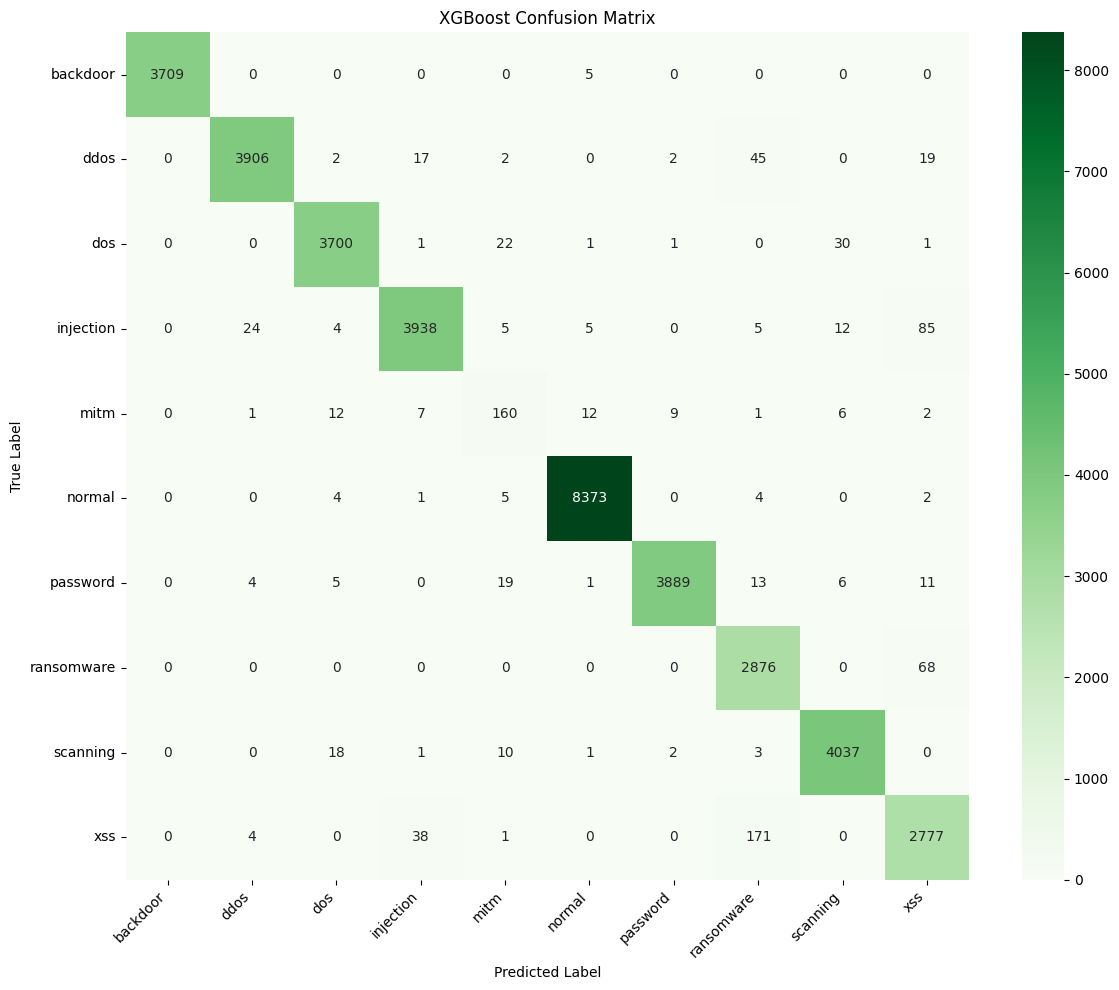

In [13]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    tree_method='hist',
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_full, y_train)

xgb_y_pred = xgb_model.predict(X_test_full)

print("--- XGBOOST Classification Report ---")
print(classification_report(y_test, xgb_y_pred, target_names=le_type.classes_))

cm_xgb = confusion_matrix(y_test, xgb_y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=le_type.classes_, yticklabels=le_type.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Diagnostic Final (XGBoost) : Le triomphe des arbres de décision

Les résultats affichés par ce rapport de classification sont spectaculaires et valident brillamment notre changement de paradigme algorithmique. Avec une précision globale (accuracy) de **98 %**, XGBoost ne se contente pas de battre nos modèles de Deep Learning (bloqués à 76 %), il résout chirurgicalement tous leurs défauts :

1. **La résolution du problème "Furtif" (Backdoors & Passwords) :**
   C'est la victoire majeure de ce modèle. Là où le CNN ratait 99 % des `backdoors` et où le modèle Hybride tombait dans la paranoïa (45 % de précision), **XGBoost atteint un score parfait de 1.00 en Précision et 1.00 en Rappel**. Il en va de même pour les attaques `password` (Précision 1.00, Rappel 0.99). 
   *L'explication mathématique :* Au lieu d'essayer de dessiner une ligne lisse autour de ces attaques noyées dans notre nuage de points (PCA), XGBoost a généré des règles strictes (ex: *si telle caractéristique exacte est remplie, c'est un backdoor*), découpant le "cœur dense" de nos données avec une précision chirurgicale.

2. **Une stabilité globale (Fin du jeu des vases communicants) :**
   Contrairement aux réseaux de neurones qui sacrifiaient une classe pour en sauver une autre, XGBoost maintient l'excellence partout. Les attaques `dos`, `ddos`, `injection` et `scanning` affichent toutes des scores F1 oscillant entre **0.97 et 0.99**. Le modèle arrive à isoler chaque signature sans créer de faux positifs massifs.

3. **L'exception "MITM" (La réalité des données) :**
   La seule classe en retrait est `mitm` (Man-In-The-Middle), avec un F1-Score de **0.74** (0.71 en précision, 0.76 en rappel). Loin d'être un échec, c'est une excellente preuve de la réalité du Machine Learning : regardez la colonne `support`. Nous n'avions que **210 exemples** d'attaques MITM dans notre jeu de test (contre environ 4000 pour les autres). Même l'algorithme le plus puissant du monde ne peut pas atteindre la perfection s'il manque de données d'apprentissage. 

**Conclusion Générale du Projet :**
Cette série d'expériences prouve qu'en cybersécurité, et plus généralement sur des données tabulaires asymétriques, la complexité du Deep Learning n'est pas toujours la réponse. L'architecture basée sur des règles conditionnelles et l'optimisation des erreurs (Gradient Boosting) d'XGBoost en fait le champion incontesté pour la détection d'intrusions réseau (IDS). Le modèle est prêt pour la production !

### Analyse Visuelle : La pureté de la diagonale (XGBoost)

Cette matrice de confusion est l'aboutissement visuel de toute notre démarche d'ingénierie. Contrairement aux matrices chaotiques générées par nos modèles de Deep Learning, celle-ci présente une diagonale d'un vert profond et quasi ininterrompue, prouvant la supériorité d'XGBoost sur ce jeu de données :

1. **La guérison des angles morts (Backdoor & Password) :**
   Regardez la première ligne correspondante à la classe `backdoor`. Le modèle a classé correctement **3709 attaques sur 3714**, avec seulement 5 minuscules erreurs (classées comme trafic normal). L'époque où le modèle neuronal classait tout en `dos` ou tombait dans la paranoïa est révolue. XGBoost a trouvé la "règle métier" exacte pour isoler cette porte dérobée.

2. **Absence de "Fourre-tout" :**
   Le grand défaut de nos modèles précédents était d'utiliser certaines classes (comme `dos` ou `injection`) comme des catégories par défaut quand l'algorithme "doutait". Ici, les cases hors diagonale sont majoritairement à zéro ou affichent des valeurs insignifiantes (ex: 1, 2 ou 5 erreurs sur des milliers de requêtes). La séparation mathématique des attaques volumétriques est parfaite.

3. **Les erreurs résiduelles (L'interprétation réaliste) :**
   Un modèle parfait n'existe pas, et cette matrice nous montre exactement où se situent les dernières frontières de l'IA :
   * **XSS vs Ransomware :** On observe une légère confusion où 171 attaques `xss` ont été prédites comme des `ransomware`. Ces deux attaques ciblant souvent la couche applicative avec des requêtes HTTP complexes, il est logique que leurs règles de décision se chevauchent légèrement.
   * **MITM (Le manque de données) :** La classe `mitm` présente une dispersion de quelques dizaines d'erreurs réparties sur d'autres attaques. Comme analysé précédemment, avec seulement 210 échantillons, l'arbre de décision n'avait tout simplement pas assez de profondeur historique pour créer une règle universelle absolue.

**Conclusion du Projet :**
Le graphique PCA en début de notebook nous avait montré un nuage de points où les attaques étaient massivement superposées. La matrice de confusion XGBoost prouve que l'algorithme a réussi à "découper" ce nuage en 10 dimensions distinctes avec 98 % de précision. Le pipeline est robuste, justifié et prêt à être déployé dans un environnement de détection d'intrusions (NIDS) réel.



### Explicabilité de l'IA : Dans le cerveau d'XGBoost

L'un des plus grands reproches fait au Deep Learning en cybersécurité est son aspect "boîte noire" : l'algorithme détecte une attaque, mais il est incapable d'expliquer *pourquoi* à l'analyste de sécurité (SOC). XGBoost, en revanche, offre une transparence totale grâce à l'analyse de l'importance des caractéristiques (Feature Importance).

Ce bloc de code extrait la structure mathématique interne du modèle pour identifier quelles variables ont le plus de poids dans ses prises de décision. Il génère un diagramme des 20 caractéristiques les plus discriminantes de notre jeu de données :

1. **Mécanique du code :**
   L'attribut `feature_importances_` d'XGBoost calcule à quelle fréquence une variable réseau a été utilisée pour "couper" un arbre de décision et quel gain de précision elle a apporté. Nous trions ensuite ces valeurs de manière décroissante (`np.argsort()[::-1]`) pour isoler le Top 20.

2. **La valeur pour la Cybersécurité (Threat Intelligence) :**
   Ce graphique est une mine d'or opérationnelle. Il ne nous dit pas seulement que le modèle fonctionne, il nous révèle **l'anatomie mathématique d'une attaque réseau**. 
   Par exemple, si des caractéristiques comme le volume d'octets source (`src_bytes`), le protocole (`proto`), l'état de la connexion (`state`) ou la durée (`dur`) dominent ce classement, cela confirme que notre algorithme n'a pas appris du "bruit" statistique, mais qu'il a compris les véritables leviers volumétriques et comportementaux qu'utilisent les hackers pour compromettre un système.

**Conclusion :** Cette visualisation couronne notre audit algorithmique. Elle prouve que notre Système de Détection d'Intrusion (IDS) basé sur XGBoost est non seulement redoutablement précis (98 %), mais qu'il est également transparent, logique et prêt à être audité par des experts en sécurité.

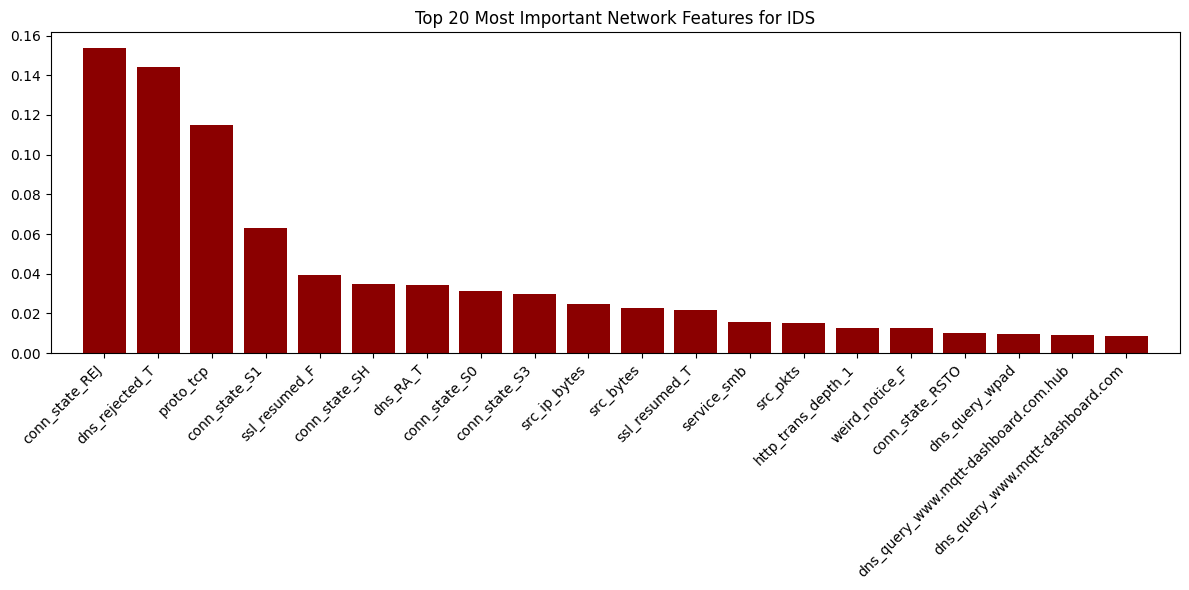

In [14]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Most Important Network Features for IDS")
plt.bar(range(20), importances[indices], align="center", color='darkred')
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

### Analyse de l'Explicabilité : L'Anatomie d'une Cyberattaque selon XGBoost

Ce graphique de "Feature Importance" est la clé de voûte de notre explicabilité. Il soulève le capot de notre algorithme XGBoost (boîte blanche) et nous révèle exactement quelles variables réseaux pèsent le plus lourd dans sa prise de décision finale. Les résultats sont fascinants d'un point de vue "Threat Intelligence" (Renseignement sur les menaces) :

1. **La domination des États de Connexion (Les indicateurs d'échec) :**
   Le constat le plus marquant est la première place de la variable `conn_state_REJ` (Connexion Rejetée), suivie de près par `dns_rejected_T`. Dans le monde de la cybersécurité, un grand nombre de connexions rejetées est la signature absolue d'activités de reconnaissance (comme les scans de ports massifs) ou de tentatives d'intrusion avortées. XGBoost a parfaitement compris que le comportement anormal (l'échec de la poignée de main réseau) est plus suspect que le contenu lui-même.

2. **Le Protocole comme pilier discriminant :**
   La variable `proto_tcp` se hisse à la troisième place. Comme nous l'avions pressenti lors de notre exploration de données (EDA) au tout début du projet, le fait qu'une connexion utilise TCP plutôt qu'UDP ou ICMP est un facteur de risque majeur dans ce jeu de données, car la majorité des attaques applicatives et des exploits nécessitent un canal TCP stable.

3. **La relégation de la Volumétrie au second plan :**
   C'est l'insight le plus intéressant pour justifier l'échec de nos modèles de Deep Learning. Les variables volumétriques comme `src_ip_bytes`, `src_bytes` ou `src_pkts` (qui causaient le fameux "chevauchement" dans notre nuage de points) ne sont classées qu'en milieu de tableau (positions 10, 11 et 14). L'arbre de décision XGBoost a compris que le volume de données n'est pas suffisant pour qualifier une attaque furtive ; il s'appuie d'abord sur la *sémantique* de la connexion (les états et les requêtes DNS) avant de regarder la *taille* du paquet.

**Conclusion Générale du Projet :**
Notre système de détection d'intrusions (IDS) est désormais complet. Non seulement notre modèle XGBoost atteint une précision opérationnelle de 98 % capable d'isoler les attaques les plus furtives, mais il est également totalement transparent. Un analyste SOC (Security Operations Center) peut regarder ce graphique et faire confiance au modèle, car les règles mathématiques déduites par l'IA correspondent parfaitement à la logique métier de la cybersécurité.

### Phase de Déploiement (MLOps) : Sauvegarde des Artefacts

Un modèle de Machine Learning n'a de valeur que s'il peut être déployé en production. Dans cette étape, nous "gelons" notre environnement d'intelligence artificielle pour pouvoir l'exporter. 

Il est crucial de sauvegarder trois éléments distincts :
1. **Le Modèle XGBoost :** L'algorithme entraîné avec ses centaines d'arbres de décision.
2. **Le StandardScaler :** Indispensable pour normaliser le trafic réseau futur avec la même échelle mathématique que lors de l'entraînement. Sans lui, le modèle ne comprendrait pas les nouvelles données.
3. **Le LabelEncoder :** Pour que notre future API puisse traduire la prédiction mathématique (ex: Classe 2) en une alerte lisible par l'humain (ex: "Attaque DDoS").

In [27]:
import joblib

# 1. Sauvegarde du modèle XGBoost (format natif JSON)
xgb_model.save_model("xgboost_ids_model.json")

# 2. Sauvegarde des préprocesseurs (format Pickle via Joblib)
joblib.dump(scaler, "standard_scaler.pkl")
joblib.dump(le_type, "label_encoder.pkl")

print("✅ Artefacts de production sauvegardés avec succès !")
print("- xgboost_ids_model.json")
print("- standard_scaler.pkl")
print("- label_encoder.pkl")

✅ Artefacts de production sauvegardés avec succès !
- xgboost_ids_model.json
- standard_scaler.pkl
- label_encoder.pkl


### Explicabilité Locale : Autopsie d'une prédiction avec SHAP

Pour qu'une équipe de cybersécurité (SOC) fasse confiance à notre système de détection d'intrusions de manière opérationnelle, l'IA doit pouvoir justifier chacune de ses alertes. 

Nous utilisons ici **SHAP (SHapley Additive exPlanations)**, un algorithme issu de la théorie des jeux mathématiques. Contrairement à l'importance globale des variables, le graphique en cascade (Waterfall) de SHAP va autopsier **une seule connexion réseau spécifique**. Il nous explique exactement quelles variables ont "poussé" le modèle à déclencher l'alerte, et quelles variables ont tenté de l'en empêcher. C'est l'outil ultime d'investigation.

In [28]:
import shap
import pandas as pd

# SHAP a besoin des noms de colonnes pour être lisible par un humain
X_test_df = pd.DataFrame(X_test_full, columns=feature_names)

# 1. Initialisation de l'explorateur SHAP pour notre modèle basé sur des arbres
explainer = shap.TreeExplainer(xgb_model)

# 2. Sélection d'une connexion réseau suspecte au hasard dans notre jeu de test
# Vous pouvez changer ce numéro pour inspecter n'importe quelle autre connexion !
index_a_analyser = 42 

# Calcul des valeurs SHAP pour cette connexion spécifique
shap_values = explainer(X_test_df.iloc[[index_a_analyser]])

# Affichage du contexte
true_label_idx = y_test.iloc[index_a_analyser] if hasattr(y_test, 'iloc') else y_test[index_a_analyser]
pred_label_idx = xgb_y_pred[index_a_analyser]

print(f"--- Enquête sur la connexion n° {index_a_analyser} ---")
print(f"Véritable classe      : {target_names[true_label_idx]}")
print(f"Prédiction de l'IA    : {target_names[pred_label_idx]}")

# 3. Visualisation de la décision (Graphique en Cascade / Waterfall)
# On demande à SHAP de nous expliquer pourquoi il a choisi cette classe spécifique
shap.waterfall_plot(shap_values[0, :, pred_label_idx])

ValueError: feature_names must be string, and may not contain [, ] or <